# Document-Type Classifier — Start Pages (Qwen-7B Transcriptions)

Multi-class classification of **document type** using **only start-page features**  
(i.e. the first page of each document segment within a dossier).

**Label source**: `dossier_labels_merged_pdf12_stratified.tsv`  
Rare document types have been merged into `Other (layout_type, functional_category)` bins,  
leaving **24 document-type classes**. The file also contains a pre-defined stratified train/val/test split at dossier level.

**Three modality families**

| # | Modality | Models |
|---|----------|--------|
| A | **Image only** | KNN+VGG-16, XGBoost+VGG-16, VGG-16 FT, EfficientNet-B0 FT, LSTM+VGG-16 |
| B | **Text only** | KNN+BERT, XGBoost+BERT, TEXT-CNN, BERT FT |
| C | **Fusion** | KNN-Ensemble, XGBoost-Ensemble, Early Fusion (EfficientNet+BERT→MLP), Late Fusion (avg softmax) |

**Data**:
- Images: `pdf_pages_png/<dossier>/<dossier>_page_XXXX.png`
- Text: `transcriptions-Qwen-7B-dossiers_3343-markdown/<trans_name>/<trans_name>_page_XXXX.markdown.md`
- Labels + split: `dossier_labels_merged_pdf12_stratified.tsv`


## 1. Setup

In [ ]:
import sys, os, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

WORKSPACE  = Path('/data/storage_hpc_1tb/CHR-2027-migration_dossiers/data')
WORKSPACE  = Path('/data/storage_hpc_1tb/CHR-2027-migration_dossiers/data')
PNG_ROOT   = WORKSPACE / 'image-per-page'
TEXT_ROOT  = WORKSPACE / 'markdown-per-page'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

BERT_MODEL = 'bert-base-uncased'


/data/storage_hpc_1tb/CHR-2027-migration_dossiers/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load Annotations & Build Labels

Labels are read from `dossier_labels_merged_pdf12_stratified.tsv`, which contains:
- **24 document-type classes** (rare types merged into `Other (layout, category)` groups).
- A **pre-defined stratified train / val / test split** at the dossier level (`split` column).
- The `pdf_id` column is the dossier name (no `.pdf` extension).

Only rows where `start_page == 'yes'` are kept.


In [6]:
df_tsv = pd.read_csv(WORKSPACE / 'labels/dossier_labels_merged_pdf12_stratified-new_identifiers.tsv', sep='\t')

# Filter to start pages only
start_pages = (
    df_tsv[df_tsv['start_page'] == 'yes']
    .dropna(subset=['document_type'])
    .copy()
    .reset_index(drop=True)
)

# Use pdf_id as the canonical dossier name (no .pdf extension)
start_pages = start_pages.rename(columns={'pdf_id': 'dossier'})

# ── Build canonical class mapping (alphabetical) ─────────────────────────────
CLASS_NAMES  = sorted(start_pages['document_type'].unique().tolist())
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# Abbreviated display names (≤30 chars) for plots
SHORT_NAMES  = [c[:28] + '…' if len(c) > 28 else c for c in CLASS_NAMES]

# Encode labels
start_pages['label'] = start_pages['document_type'].map(CLASS_TO_IDX).astype(int)

print(f'Total start pages : {len(start_pages)}')
print(f'Document types    : {NUM_CLASSES}')
print(f'Split counts      : {start_pages["split"].value_counts().to_dict()}')
print()

dist = start_pages['label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx:2d}  {CLASS_NAMES[idx]:<55s}  {count:4d}  ({count/len(start_pages)*100:.1f}%)')


Total start pages : 1718
Document types    : 25
Split counts      : {'train': 1187, 'val': 313, 'test': 218}

   0  Approval notice                                            62  (3.6%)
   1  D.1                                                       136  (7.9%)
   2  D.2                                                       119  (6.9%)
   3  DM.1                                                      146  (8.5%)
   4  Form No. 63 (Rijksarbeidsbureau - Qualifications)           1  (0.1%)
   5  Judicial and political background check                   104  (6.1%)
   6  Letter about procedure (Other)                            125  (7.3%)
   7  NAA cover                                                  65  (3.8%)
   8  NAMA agreement                                             75  (4.4%)
   9  Other (Letter, Application Documents)                       5  (0.3%)
  10  Other (Letter, Medical & Health Documents)                  9  (0.5%)
  11  Other (Letter, Other)                           

## 3. Build Image & Text Paths

Image paths are resolved against `pdf_pages_png/`.  
Text paths use the Qwen-7B markdown transcriptions; `ann_to_trans_name()` converts the
dash-separated dossier name to the underscore-in-name convention used by the transcription folders.


In [7]:
def ann_to_trans_name(dossier: str) -> str:
    """Map annotation dossier name (dash-separated) to Qwen transcription folder name.

    e.g. 'a2478-boer-j-1452187' → 'a2478-boer_j-1452187'
    """
    parts = dossier.split('-')
    return f"{parts[0]}-{'_'.join(parts[1:-1])}-{parts[-1]}"

def page_png_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

def page_text_path(dossier: str, page_num: int) -> Path:
    trans_name = ann_to_trans_name(dossier)
    return TEXT_ROOT / trans_name / f'{trans_name}_page_{int(page_num):04d}.markdown.md'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

start_pages['img_path']  = start_pages.apply(
    lambda r: page_png_path(r['dossier'], r['page_num']), axis=1)
start_pages['text_path'] = start_pages.apply(
    lambda r: page_text_path(r['dossier'], r['page_num']), axis=1)

img_exist  = start_pages['img_path'].map(lambda p: p.exists()).mean()
text_exist = start_pages['text_path'].map(lambda p: p.exists()).mean()
print(f'PNG  files found: {img_exist:.1%}  |  Text files found: {text_exist:.1%}')

# Keep only pages whose PNG exists (required for visual models)
start_pages = start_pages[
    start_pages['img_path'].map(lambda p: p.exists())
].reset_index(drop=True)
print(f'Start pages with valid image: {len(start_pages)}')
start_pages.head()


PNG  files found: 100.0%  |  Text files found: 100.0%
Start pages with valid image: 1718


,pdf_name,page_num,n_annotators,document_type,document_type_agreement,layout_type,layout_type_agreement,functional_category,functional_category_agreement,start_page,start_page_agreement,img_path,text_path,split,dossier,identifier,pagexml_path,markdown_path,label
0,a2478-ambachtsheer_p-1214053,1,1,NAA cover,single,Cover,single,Other,single,yes,single,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,train,a2478-ambachtsheer_p-1214053,1214053,data/pagexml-per-page/a2478-ambachtsheer_p-121...,data/markdown-per-page/a2478-ambachtsheer_p-12...,7
1,a2478-ambachtsheer_p-1214053,2,1,Photo,single,Photo,single,Other,single,yes,single,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,train,a2478-ambachtsheer_p-1214053,1214053,data/pagexml-per-page/a2478-ambachtsheer_p-121...,data/markdown-per-page/a2478-ambachtsheer_p-12...,18
2,a2478-ambachtsheer_p-1214053,4,1,D.1,single,Structured Form,single,Application Documents,single,yes,single,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,train,a2478-ambachtsheer_p-1214053,1214053,data/pagexml-per-page/a2478-ambachtsheer_p-121...,data/markdown-per-page/a2478-ambachtsheer_p-12...,1
3,a2478-ambachtsheer_p-1214053,6,1,Testimonial medical letter (Medical & Health D...,single,Other,single,Medical & Health Documents,single,yes,single,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,train,a2478-ambachtsheer_p-1214053,1214053,data/pagexml-per-page/a2478-ambachtsheer_p-121...,data/markdown-per-page/a2478-ambachtsheer_p-12...,23
4,a2478-ambachtsheer_p-1214053,7,1,"Other (Structured Form, Administrative & Inter...",single,Structured Form,single,Administrative & Internal Processing Documents,single,yes,single,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,/data/storage_hpc_1tb/CHR-2027-migration_dossi...,train,a2478-ambachtsheer_p-1214053,1214053,data/pagexml-per-page/a2478-ambachtsheer_p-121...,data/markdown-per-page/a2478-ambachtsheer_p-12...,13


## 4. Train / Validation / Test Split

The split is taken directly from the `split` column in the TSV file  
(dossier-level stratification was applied when the file was created).


In [8]:
# Use the pre-defined split from the TSV
for s in ['train', 'val', 'test']:
    sub = start_pages[start_pages['split'] == s]
    n_cls = sub['label'].nunique()
    print(f'{s:6s}: {len(sub):4d} start pages  |  {n_cls} distinct doc-types')

idx_tr = start_pages[start_pages['split'] == 'train'].index
idx_va = start_pages[start_pages['split'] == 'val'].index
idx_te = start_pages[start_pages['split'] == 'test'].index

df_tr = start_pages.loc[idx_tr]
df_va = start_pages.loc[idx_va]
df_te = start_pages.loc[idx_te]

y_tr = start_pages.loc[idx_tr, 'label'].values
y_va = start_pages.loc[idx_va, 'label'].values
y_te = start_pages.loc[idx_te, 'label'].values


train : 1187 start pages  |  25 distinct doc-types
val   :  313 start pages  |  23 distinct doc-types
test  :  218 start pages  |  22 distinct doc-types


## 5. Feature Extraction

All features are extracted for the **start-page subset**.
Cache files use the suffix `_doctype` to avoid collisions with other notebooks.


### 5a. VGG-16 Image Features (cached)

4096-D penultimate FC features from pre-trained VGG-16 (ImageNet).


In [10]:
sys.path.insert(0, str(WORKSPACE))
from classification.page_classifier_features import VGG16FeatureExtractor

VGG_FULL_CACHE  = CACHE_DIR / 'vgg16_features.npz'
VGG_CACHE       = CACHE_DIR / 'vgg16_features_doctype.npz'

def _load_vgg_cache(cache_path):
    c = np.load(cache_path, allow_pickle=True)
    return c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}

X_vgg    = np.zeros((len(start_pages), 4096), dtype=np.float32)
img_strs = start_pages['img_path'].map(str)

for cache_path in [VGG_FULL_CACHE, VGG_CACHE]:
    if cache_path.exists():
        X_cache, path_map = _load_vgg_cache(cache_path)
        hit = img_strs.map(lambda p: p in path_map)
        if hit.all():
            X_vgg = X_cache[img_strs.map(lambda p: path_map[p]).values]
            print(f'All {len(X_vgg)} VGG features loaded from {cache_path.name}.')
            break
        hit_idx  = start_pages[hit].index
        miss_idx = start_pages[~hit].index
        X_vgg[hit_idx] = X_cache[img_strs[hit_idx].map(lambda p: path_map[p]).values]
        print(f'{hit.sum()} from cache; extracting {(~hit).sum()} missing …')
        vgg_ext = VGG16FeatureExtractor(device=DEVICE)
        X_vgg[miss_idx] = vgg_ext.encode_paths(start_pages.loc[miss_idx, 'img_path'].tolist())
        np.savez_compressed(VGG_CACHE, X_all=X_vgg, path_strs=img_strs.values)
        break
else:
    print('Extracting VGG-16 features from scratch …')
    vgg_ext = VGG16FeatureExtractor(device=DEVICE)
    X_vgg   = vgg_ext.encode_paths(start_pages['img_path'].tolist(), batch_size=16)
    np.savez_compressed(VGG_CACHE, X_all=X_vgg, path_strs=img_strs.values)
    print(f'Saved {len(X_vgg)} features → {VGG_CACHE.name}')

X_vgg_tr = X_vgg[idx_tr]
X_vgg_va = X_vgg[idx_va]
X_vgg_te = X_vgg[idx_te]
print(f'VGG  train: {X_vgg_tr.shape}, val: {X_vgg_va.shape}, test: {X_vgg_te.shape}')


Extracting VGG-16 features from scratch …
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/mkoolen/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 354MB/s] 


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
For more detailed error information, run with CUDA_LOG_FILE=stderr


### 5b. EfficientNet-B0 Image Features (cached)

1280-D global-average-pooled features from pre-trained EfficientNet-B0.


In [ ]:
EFF_FULL_CACHE = CACHE_DIR / 'efficientnet_features_layout.npz'
EFF_CACHE      = CACHE_DIR / 'efficientnet_features_doctype.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = models.efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            chunk = paths[start:start + batch_size]
            tensors = []
            for p in chunk:
                with Image.open(p).convert('RGB') as im:
                    tensors.append(preprocess(im))
            feat = eff(torch.stack(tensors).to(DEVICE)).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X

X_eff    = np.zeros((len(start_pages), 1280), dtype=np.float32)
img_strs = start_pages['img_path'].map(str)

for cache_path in [EFF_FULL_CACHE, EFF_CACHE]:
    if cache_path.exists():
        c = np.load(cache_path, allow_pickle=True)
        X_c, path_map = c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}
        hit = img_strs.map(lambda p: p in path_map)
        if hit.all():
            X_eff = X_c[img_strs.map(lambda p: path_map[p]).values]
            print(f'All {len(X_eff)} EfficientNet features from {cache_path.name}.')
            break
        hit_idx, miss_idx = start_pages[hit].index, start_pages[~hit].index
        X_eff[hit_idx]  = X_c[img_strs[hit_idx].map(lambda p: path_map[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(
            start_pages.loc[miss_idx, 'img_path'].tolist())
        np.savez_compressed(EFF_CACHE, X_all=X_eff, path_strs=img_strs.values)
        print(f'{hit.sum()} from cache + {(~hit).sum()} extracted → {EFF_CACHE.name}')
        break
else:
    print('Extracting EfficientNet-B0 from scratch …')
    X_eff = extract_efficientnet_features(start_pages['img_path'].tolist())
    np.savez_compressed(EFF_CACHE, X_all=X_eff, path_strs=img_strs.values)
    print(f'Saved {len(X_eff)} features → {EFF_CACHE.name}')

X_eff_tr = X_eff[idx_tr]
X_eff_va = X_eff[idx_va]
X_eff_te = X_eff[idx_te]
print(f'EfficientNet  train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')


1693 from cache + 8 extracted → efficientnet_features_doctype.npz
EfficientNet  train: (1179, 1280), val: (307, 1280), test: (215, 1280)


### 5c. BERT [CLS] Text Features — Qwen-7B Transcriptions (cached)

768-D `[CLS]` token embeddings from frozen `bert-base-uncased`.
Text is sourced from the Qwen-7B markdown transcriptions.


In [ ]:
BERT_CACHE = CACHE_DIR / 'bert_features_qwen_doctype.npz'

def extract_bert_cls_features(
    text_paths: list,
    model_name: str = BERT_MODEL,
    batch_size: int = 32,
    max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False

    texts  = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            X[start:start + len(chunk)] = out.last_hidden_state[:, 0, :].cpu().numpy()
    return X

X_bert   = np.zeros((len(start_pages), 768), dtype=np.float32)
txt_strs = start_pages['text_path'].map(str)

if BERT_CACHE.exists():
    c = np.load(BERT_CACHE, allow_pickle=True)
    X_c, path_map = c['X_all'], {p: i for i, p in enumerate(c['path_strs'])}
    hit = txt_strs.map(lambda p: p in path_map)
    if hit.all():
        X_bert = X_c[txt_strs.map(lambda p: path_map[p]).values]
        print(f'All {len(X_bert)} BERT features loaded from {BERT_CACHE.name}.')
    else:
        hit_idx, miss_idx = start_pages[hit].index, start_pages[~hit].index
        X_bert[hit_idx]  = X_c[txt_strs[hit_idx].map(lambda p: path_map[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(
            start_pages.loc[miss_idx, 'text_path'].tolist())
        np.savez_compressed(BERT_CACHE, X_all=X_bert, path_strs=txt_strs.values)
        print(f'{hit.sum()} from cache + {(~hit).sum()} extracted → {BERT_CACHE.name}')
else:
    print('Extracting BERT [CLS] features from Qwen transcriptions …')
    X_bert = extract_bert_cls_features(start_pages['text_path'].tolist())
    np.savez_compressed(BERT_CACHE, X_all=X_bert, path_strs=txt_strs.values)
    print(f'Saved {len(X_bert)} features → {BERT_CACHE.name}')

X_bert_tr = X_bert[idx_tr]
X_bert_va = X_bert[idx_va]
X_bert_te = X_bert[idx_te]
print(f'BERT  train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')


Extracting BERT [CLS] features from Qwen transcriptions …
Saved 1701 features → bert_features_qwen_doctype.npz
BERT  train: (1179, 768), val: (307, 768), test: (215, 768)


## 6. Utility Helpers

In [ ]:
results = {}

def class_weights_tensor(y: np.ndarray, n_classes: int, device) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = 1.0 / counts
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32).to(device)


def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray,
             split: str = 'test') -> dict:
    acc   = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'\n── {name} [{split}] ──')
    print(f'  Accuracy: {acc:.4f}  |  Macro-F1: {macro:.4f}')
    # Full per-class report (abbreviated names to keep it readable)
    present = sorted(set(y_true) | set(y_pred))
    tgt_names = [SHORT_NAMES[i] for i in present]
    print(classification_report(y_true, y_pred, labels=present,
                                 target_names=tgt_names, zero_division=0))
    # Confusion matrix — only plot when classes are few enough
    if NUM_CLASSES <= 30:
        cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
        fig, ax = plt.subplots(figsize=(14, 12))
        ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, colorbar=False)
        ax.set_title(f'{name} — {split}')
        plt.xticks(rotation=45, ha='right', fontsize=7)
        plt.yticks(fontsize=7)
        plt.tight_layout()
        plt.show()
    return {'accuracy': acc, 'macro_f1': macro}


# ── Shared image transforms ───────────────────────────────────────────────────
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class PageImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['label'].tolist()
        self.tf     = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]).convert('RGB') as im:
            img = self.tf(im)
        return img, self.labels[i]


def make_image_loaders(df_tr, df_va, df_te, batch=32):
    tr = DataLoader(PageImageDataset(df_tr, TRAIN_TF), batch_size=batch, shuffle=True,  num_workers=0)
    va = DataLoader(PageImageDataset(df_va, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    te = DataLoader(PageImageDataset(df_te, EVAL_TF),  batch_size=batch, shuffle=False, num_workers=0)
    return tr, va, te


def train_finetune(model, tr_loader, va_loader, n_epochs=15, lr=1e-4, weight_decay=1e-5):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for xb, _ in va_loader:
                preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_image_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Helpers defined.')


Helpers defined.


---
## 7. Image-Only Models

### 7a. KNN + VGG-16

k= 3  val macro-F1=0.5249
k= 5  val macro-F1=0.5196


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


k= 7  val macro-F1=0.4840
k=11  val macro-F1=0.4619
k=15  val macro-F1=0.4457

Best k=3

── KNN-VGG16 [val] ──
  Accuracy: 0.6645  |  Macro-F1: 0.5249
                               precision    recall  f1-score   support

              Approval notice       0.64      1.00      0.78        14
                          D.1       0.70      1.00      0.82        16
                          D.2       0.83      0.80      0.82        25
                         DM.1       0.85      1.00      0.92        22
Judicial and political backg…       0.81      1.00      0.90        22
Letter about procedure (Othe…       0.62      0.13      0.22        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.65      1.00      0.79        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00       

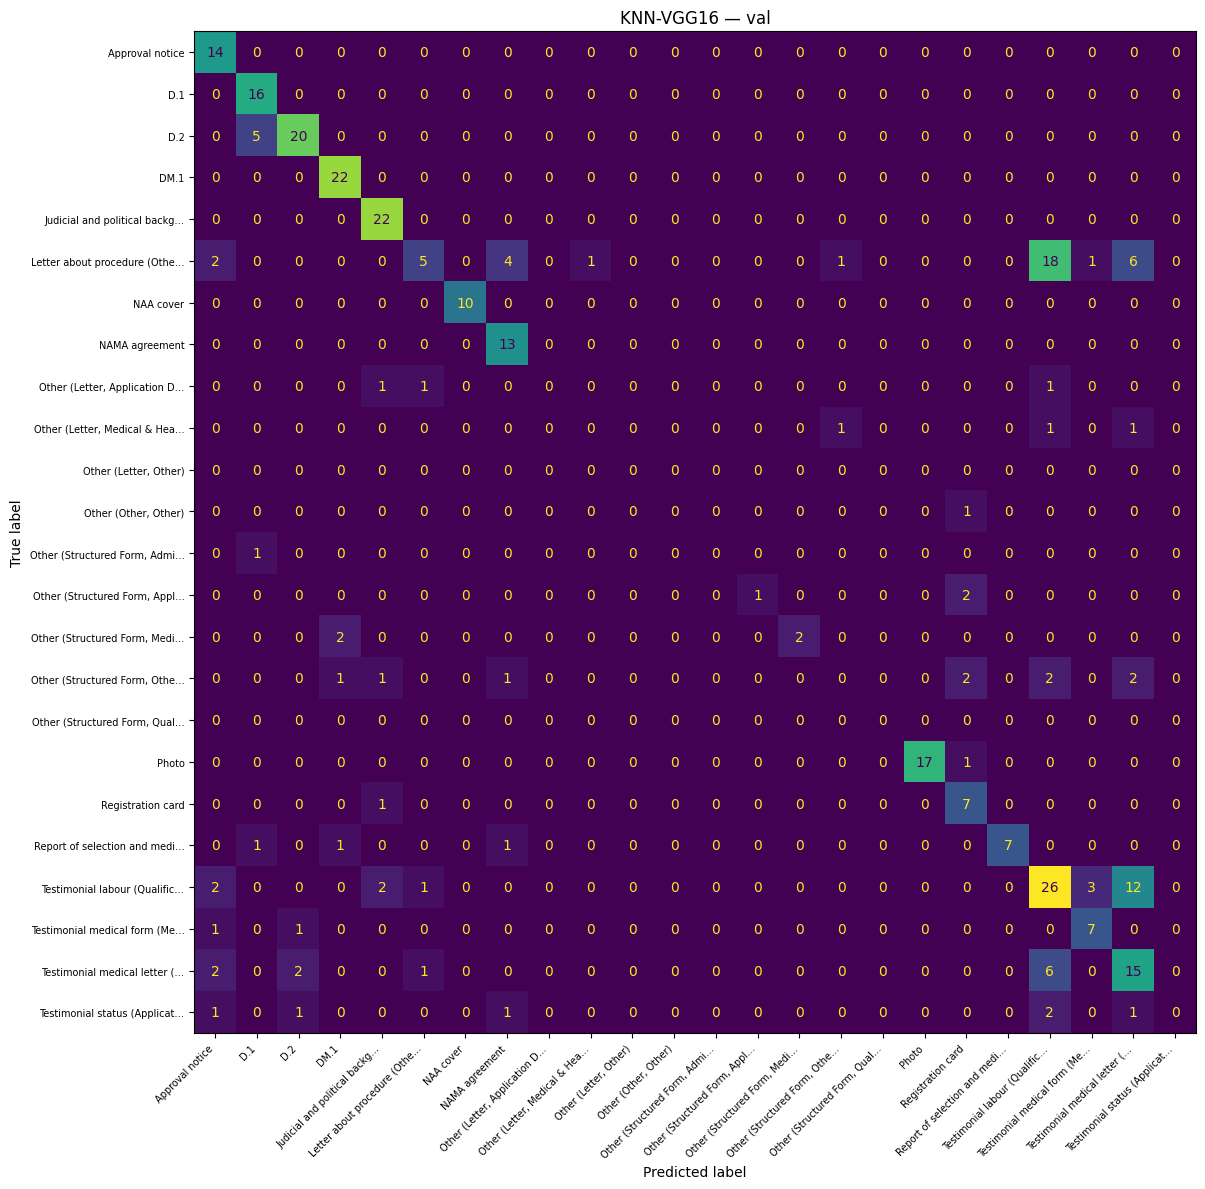


── KNN-VGG16 [test] ──
  Accuracy: 0.7116  |  Macro-F1: 0.4753
                               precision    recall  f1-score   support

              Approval notice       0.38      0.83      0.53         6
                          D.1       0.86      1.00      0.92        18
                          D.2       0.88      0.88      0.88        16
                         DM.1       0.70      1.00      0.82        16
Judicial and political backg…       0.80      1.00      0.89        12
Letter about procedure (Othe…       0.20      0.25      0.22         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.82      1.00      0.90         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (Struc

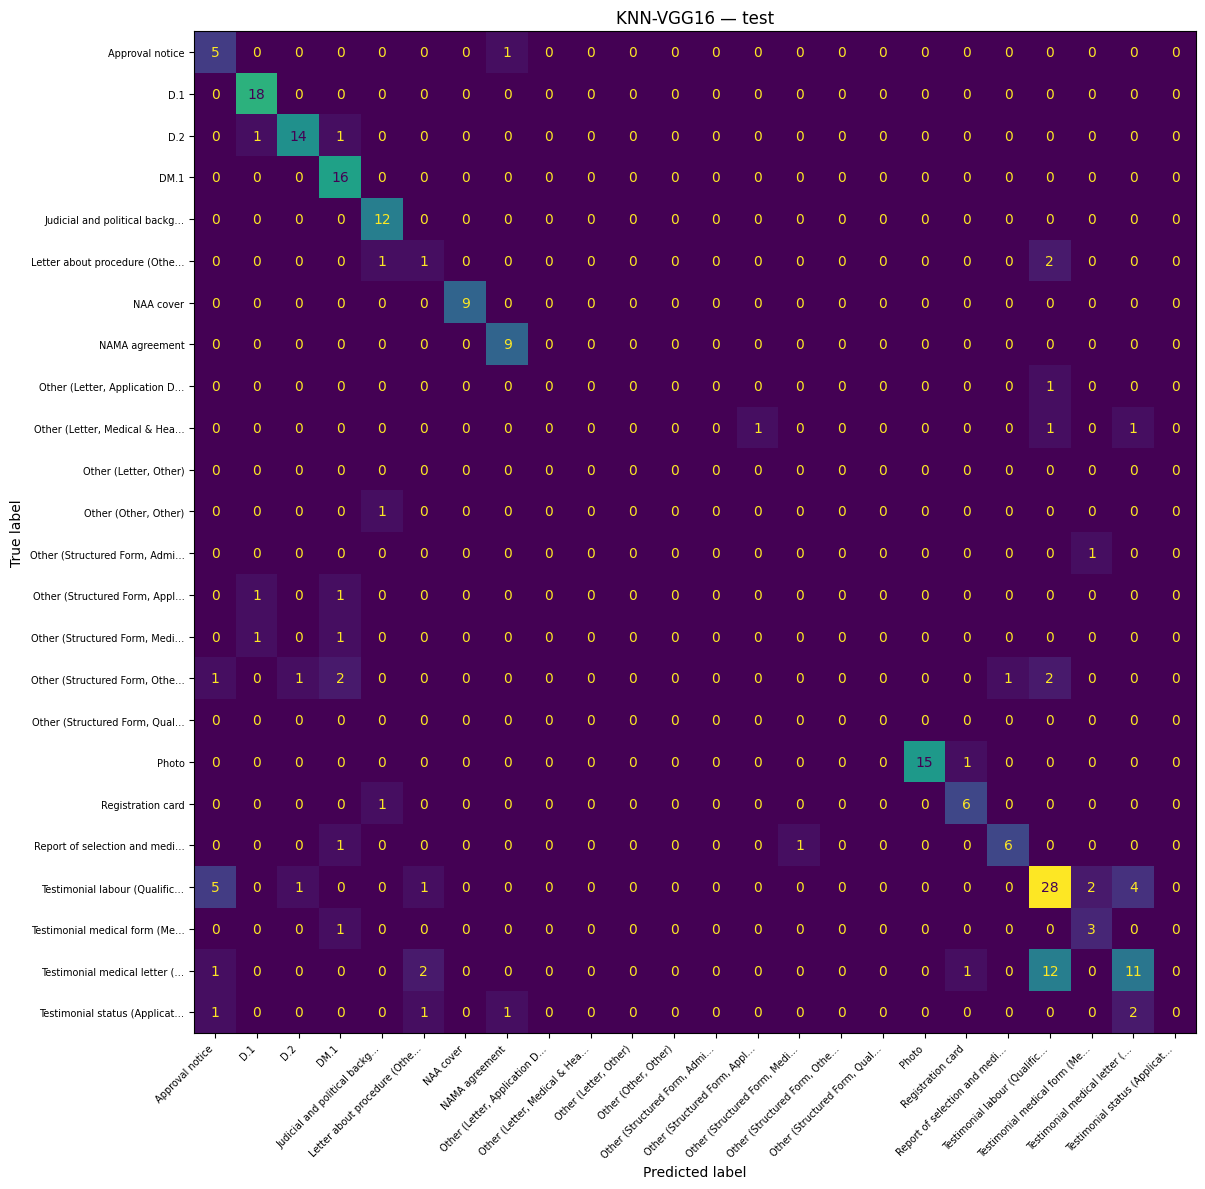

In [ ]:
X_vgg_tr_n = normalize(X_vgg_tr)
X_vgg_va_n = normalize(X_vgg_va)
X_vgg_te_n = normalize(X_vgg_te)

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_vgg_tr_n, y_tr)
    f1 = f1_score(y_va, knn.predict(X_vgg_va_n), average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_vgg = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_vgg.fit(X_vgg_tr_n, y_tr)
pred_knn_vgg_te = knn_vgg.predict(X_vgg_te_n)

evaluate('KNN-VGG16', y_va, knn_vgg.predict(X_vgg_va_n), 'val')
results['KNN-VGG16'] = evaluate('KNN-VGG16', y_te, pred_knn_vgg_te, 'test')
results['KNN-VGG16']['preds_te'] = pred_knn_vgg_te


### 7b. XGBoost + VGG-16


── XGBoost-VGG16 [val] ──
  Accuracy: 0.6906  |  Macro-F1: 0.5406
                               precision    recall  f1-score   support

              Approval notice       1.00      0.86      0.92        14
                          D.1       0.83      0.94      0.88        16
                          D.2       0.88      0.88      0.88        25
                         DM.1       0.69      1.00      0.81        22
Judicial and political backg…       0.85      1.00      0.92        22
Letter about procedure (Othe…       0.67      0.11      0.18        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.93      1.00      0.96        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       1.00      1.00      1.00         1
Other (St

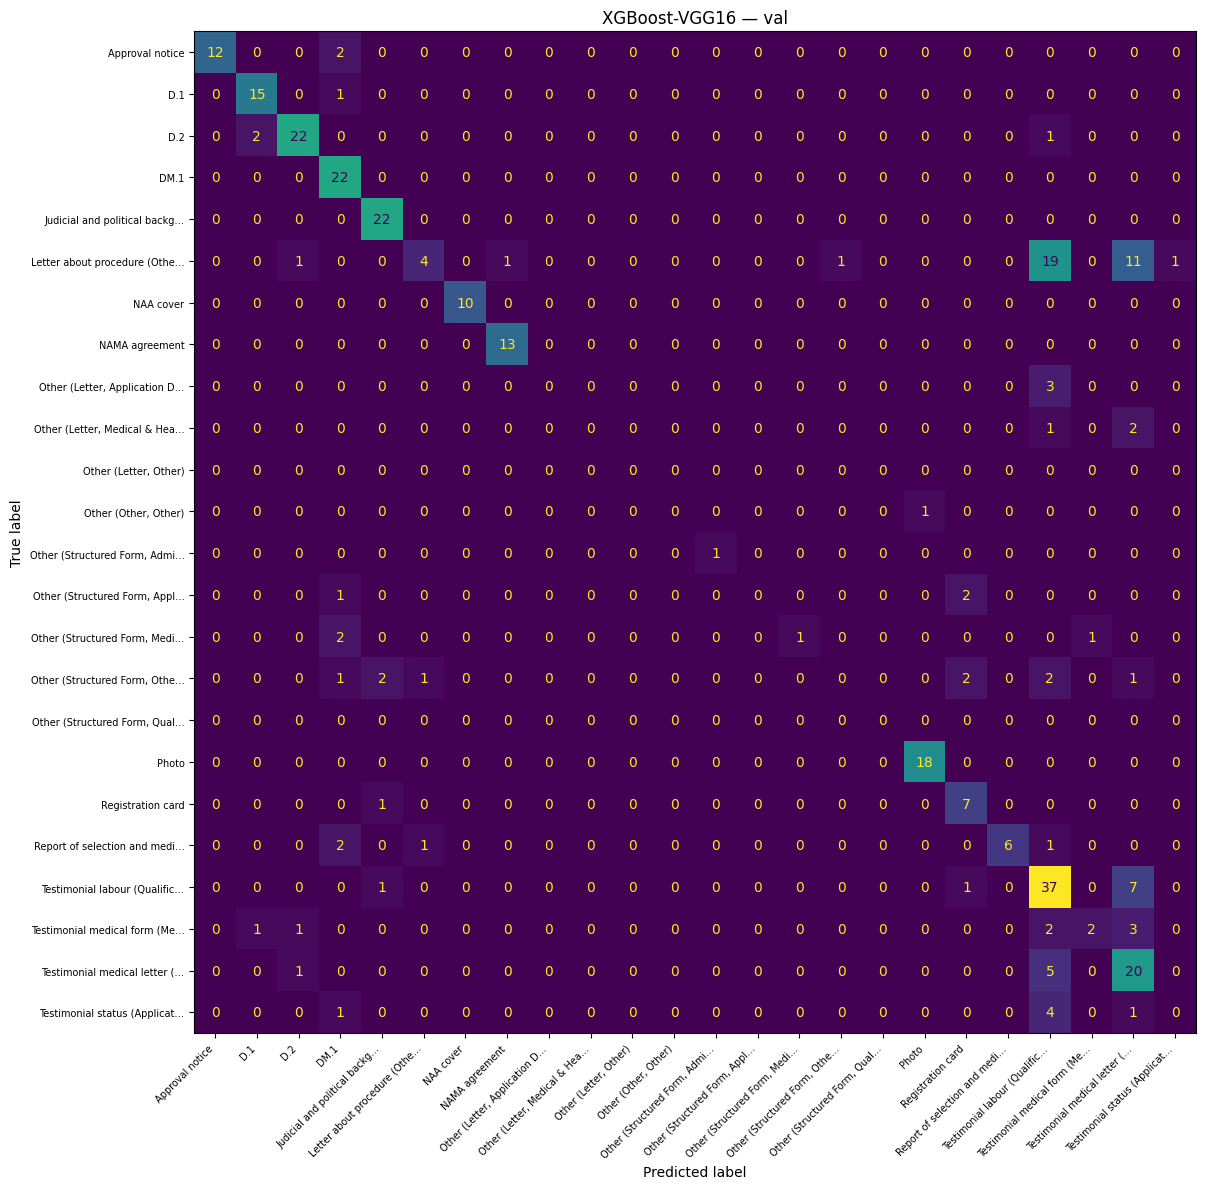


── XGBoost-VGG16 [test] ──
  Accuracy: 0.7628  |  Macro-F1: 0.5097
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.68      0.94      0.79        16
Judicial and political backg…       0.92      1.00      0.96        12
Letter about procedure (Othe…       0.00      0.00      0.00         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.90      1.00      0.95         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (S

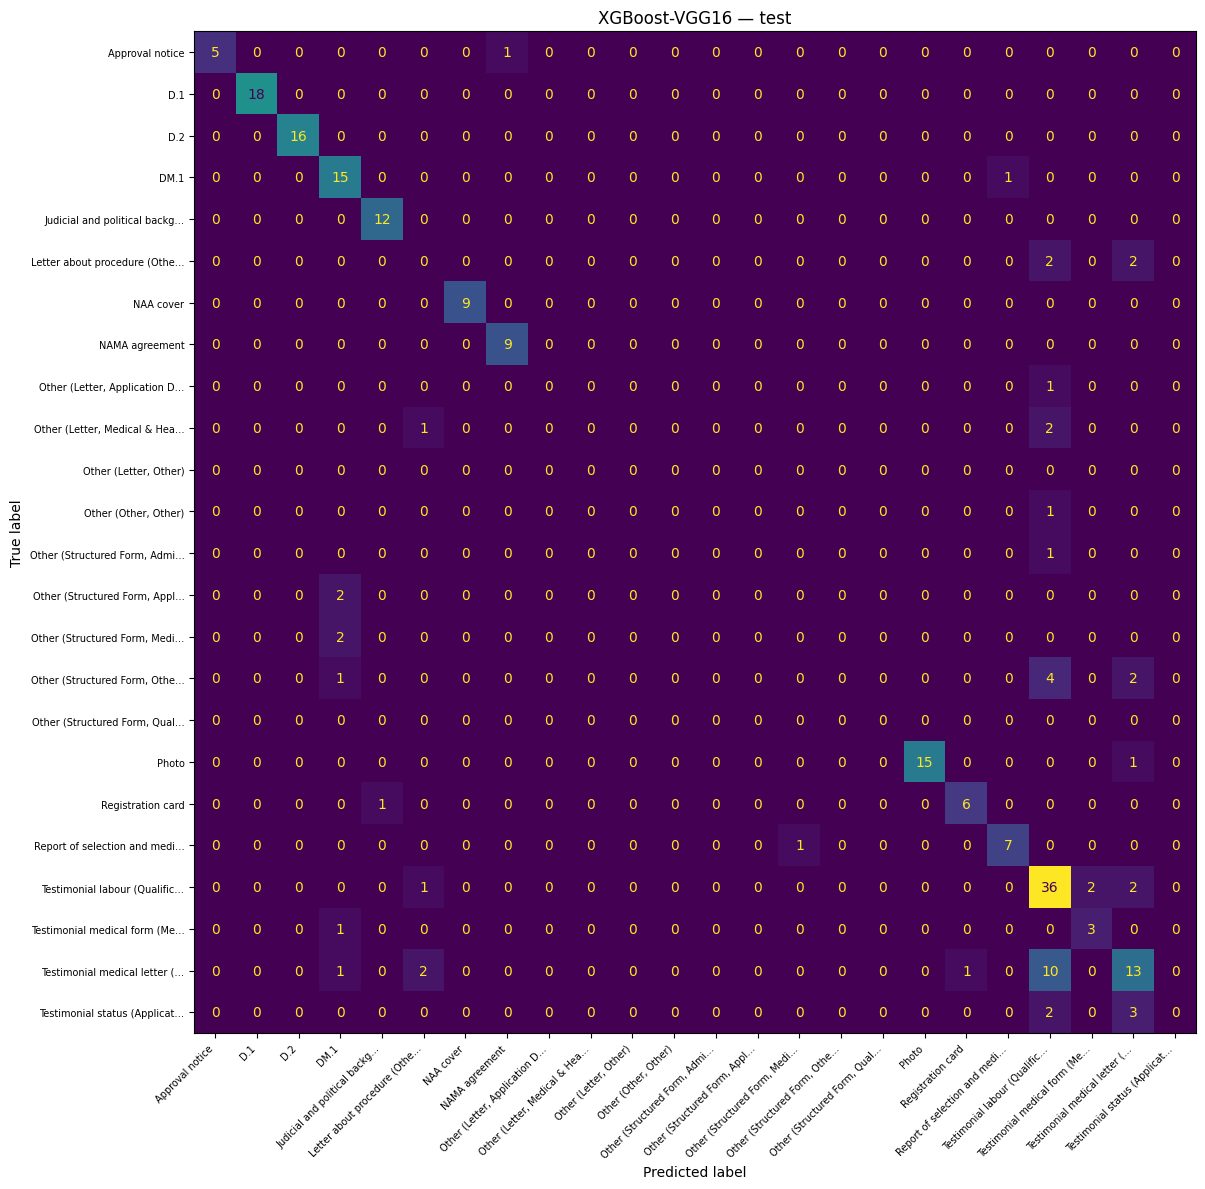

In [ ]:
xgb_vgg = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_vgg.fit(X_vgg_tr, y_tr, eval_set=[(X_vgg_va, y_va)], verbose=False)
pred_xgb_vgg_te = xgb_vgg.predict(X_vgg_te)

evaluate('XGBoost-VGG16', y_va, xgb_vgg.predict(X_vgg_va), 'val')
results['XGBoost-VGG16'] = evaluate('XGBoost-VGG16', y_te, pred_xgb_vgg_te, 'test')
results['XGBoost-VGG16']['preds_te'] = pred_xgb_vgg_te


### 7c. VGG-16 Fine-Tuned (end-to-end)

Training VGG-16 fine-tuned …
  Epoch  1  val_macro_f1=0.3462
  Epoch  2  val_macro_f1=0.4708
  Epoch  3  val_macro_f1=0.4295
  Epoch  4  val_macro_f1=0.5349
  Epoch  5  val_macro_f1=0.4807
  Epoch  6  val_macro_f1=0.5281
  Epoch  7  val_macro_f1=0.5418
  Epoch  8  val_macro_f1=0.5616
  Epoch  9  val_macro_f1=0.5616
  Epoch 10  val_macro_f1=0.5270
  Epoch 11  val_macro_f1=0.5960
  Epoch 12  val_macro_f1=0.6052
  Epoch 13  val_macro_f1=0.5946
  Epoch 14  val_macro_f1=0.6231
  Epoch 15  val_macro_f1=0.6473

── VGG16-FT [val] ──
  Accuracy: 0.7687  |  Macro-F1: 0.6473
                               precision    recall  f1-score   support

              Approval notice       0.74      1.00      0.85        14
                          D.1       0.94      1.00      0.97        16
                          D.2       1.00      0.84      0.91        25
                         DM.1       0.88      1.00      0.94        22
Judicial and political backg…       0.95      0.86      0.90        22
Le

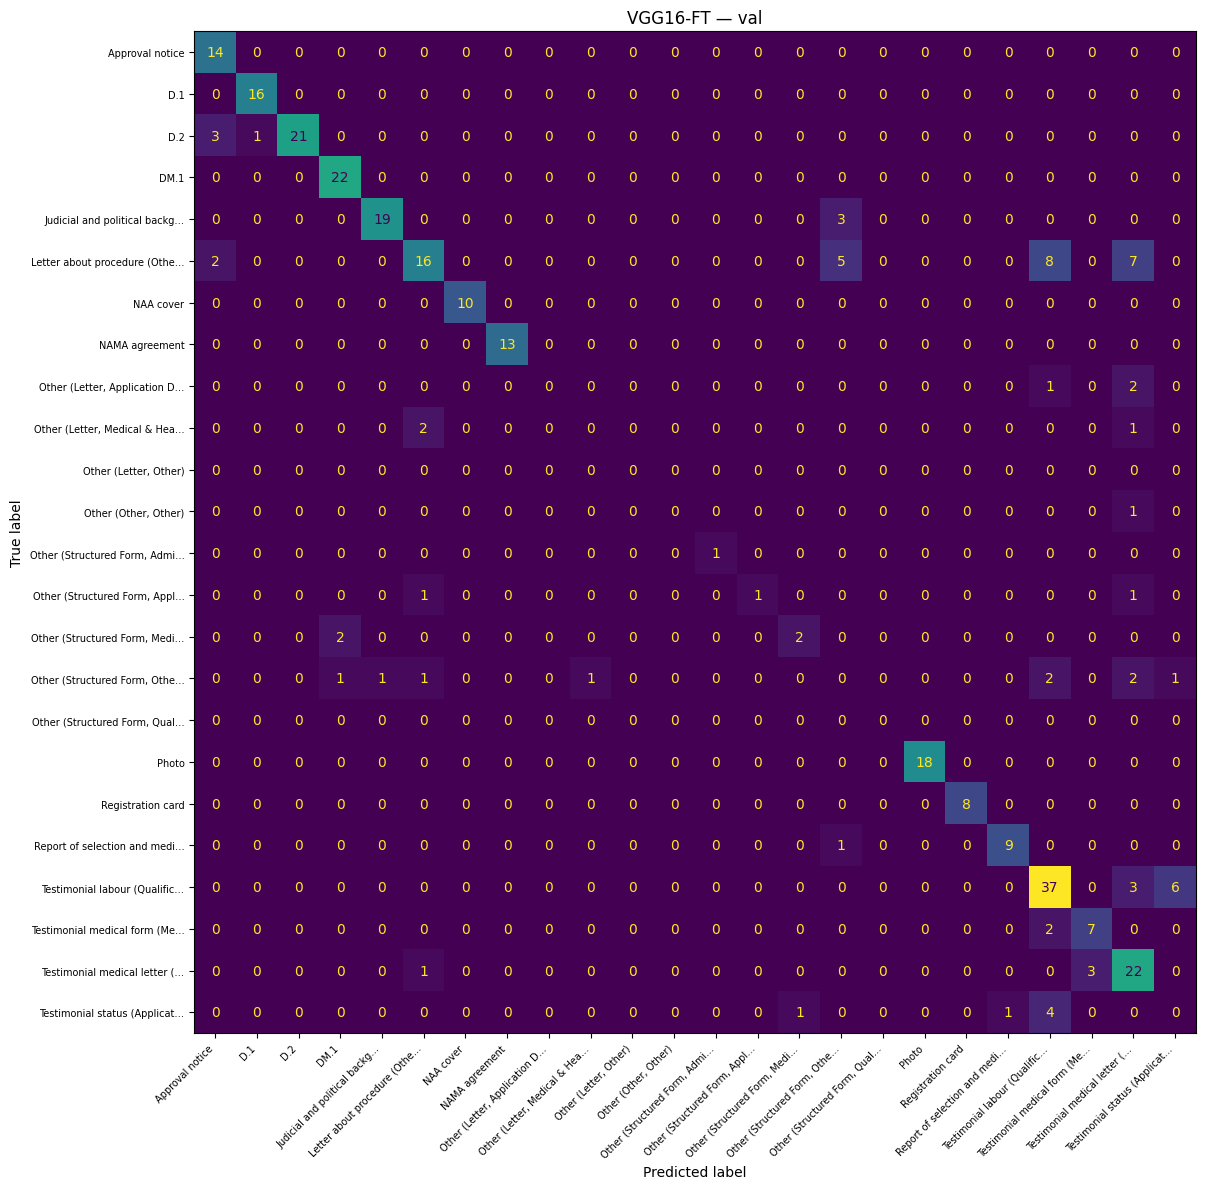


── VGG16-FT [test] ──
  Accuracy: 0.7116  |  Macro-F1: 0.5070
                               precision    recall  f1-score   support

              Approval notice       0.83      0.83      0.83         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.84      1.00      0.91        16
Judicial and political backg…       1.00      1.00      1.00        12
Letter about procedure (Othe…       0.00      0.00      0.00         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.90      1.00      0.95         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
        Other (Letter, Other)       0.00      0.00      0.00         0
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Struct

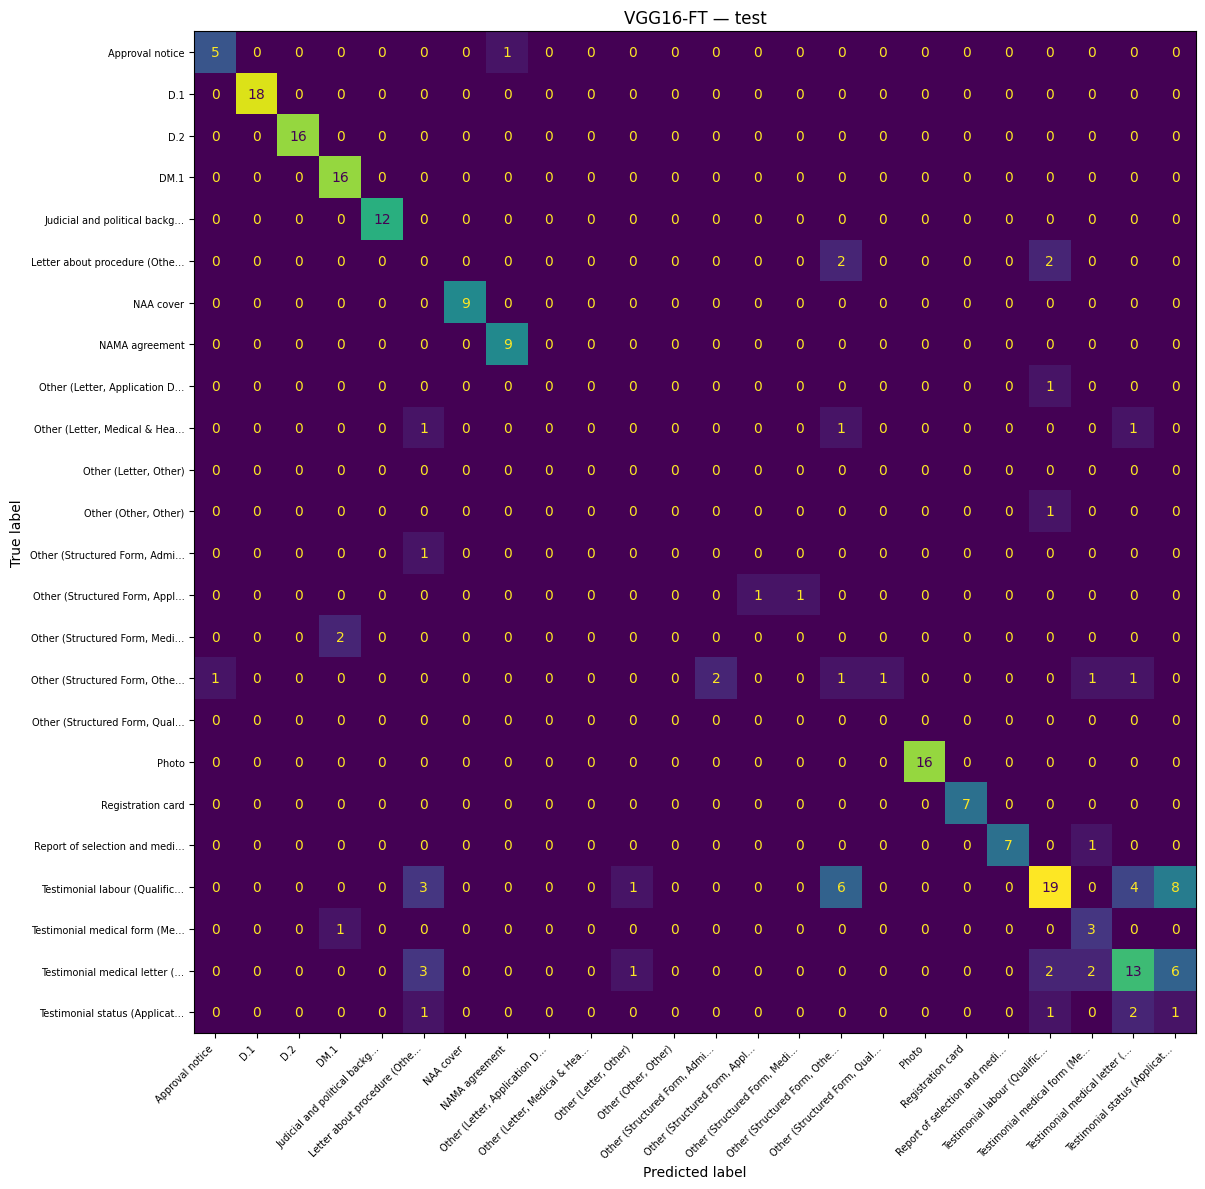

In [ ]:
tr_img_loader, va_img_loader, te_img_loader = make_image_loaders(df_tr, df_va, df_te)

vgg_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg_ft.classifier[6] = nn.Linear(4096, NUM_CLASSES)
vgg_ft = vgg_ft.to(DEVICE)

print('Training VGG-16 fine-tuned …')
vgg_ft = train_finetune(vgg_ft, tr_img_loader, va_img_loader, n_epochs=15)
pred_vgg_ft_te, probs_vgg_ft = predict_image_model(vgg_ft, te_img_loader)

evaluate('VGG16-FT', y_va, predict_image_model(vgg_ft, va_img_loader)[0], 'val')
results['VGG16-FT'] = evaluate('VGG16-FT', y_te, pred_vgg_ft_te, 'test')
results['VGG16-FT']['preds_te'] = pred_vgg_ft_te
results['VGG16-FT']['probs_te'] = probs_vgg_ft


### 7d. EfficientNet-B0 Fine-Tuned (end-to-end)

Training EfficientNet-B0 fine-tuned …
  Epoch  1  val_macro_f1=0.3255
  Epoch  2  val_macro_f1=0.3789
  Epoch  3  val_macro_f1=0.4189
  Epoch  4  val_macro_f1=0.4884
  Epoch  5  val_macro_f1=0.5198
  Epoch  6  val_macro_f1=0.5256
  Epoch  7  val_macro_f1=0.5589
  Epoch  8  val_macro_f1=0.5678
  Epoch  9  val_macro_f1=0.5751
  Epoch 10  val_macro_f1=0.5835
  Epoch 11  val_macro_f1=0.5805
  Epoch 12  val_macro_f1=0.5870
  Epoch 13  val_macro_f1=0.5866
  Epoch 14  val_macro_f1=0.5914
  Epoch 15  val_macro_f1=0.5799

── EfficientNet-FT [val] ──
  Accuracy: 0.6938  |  Macro-F1: 0.5914
                               precision    recall  f1-score   support

              Approval notice       0.79      0.79      0.79        14
                          D.1       0.94      1.00      0.97        16
                          D.2       1.00      0.96      0.98        25
                         DM.1       0.85      1.00      0.92        22
Judicial and political backg…       0.79      0.86      0

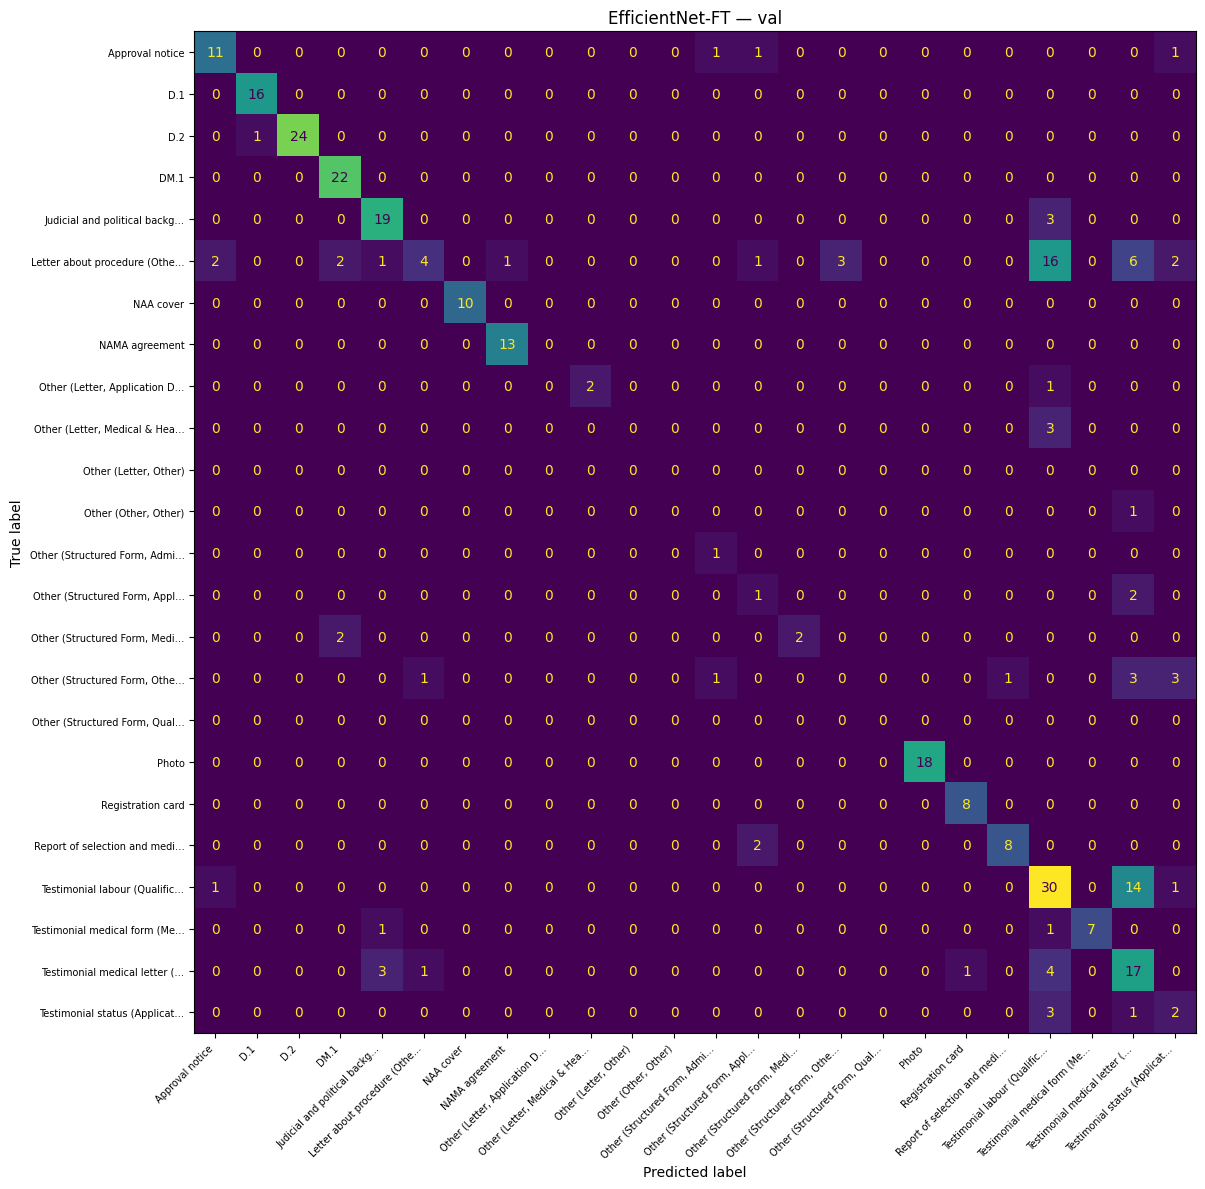


── EfficientNet-FT [test] ──
  Accuracy: 0.7767  |  Macro-F1: 0.6307
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       0.95      1.00      0.97        18
                          D.2       0.89      1.00      0.94        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.86      1.00      0.92        12
Letter about procedure (Othe…       0.00      0.00      0.00         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.90      1.00      0.95         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.33      1.00      0.50         1
Other 

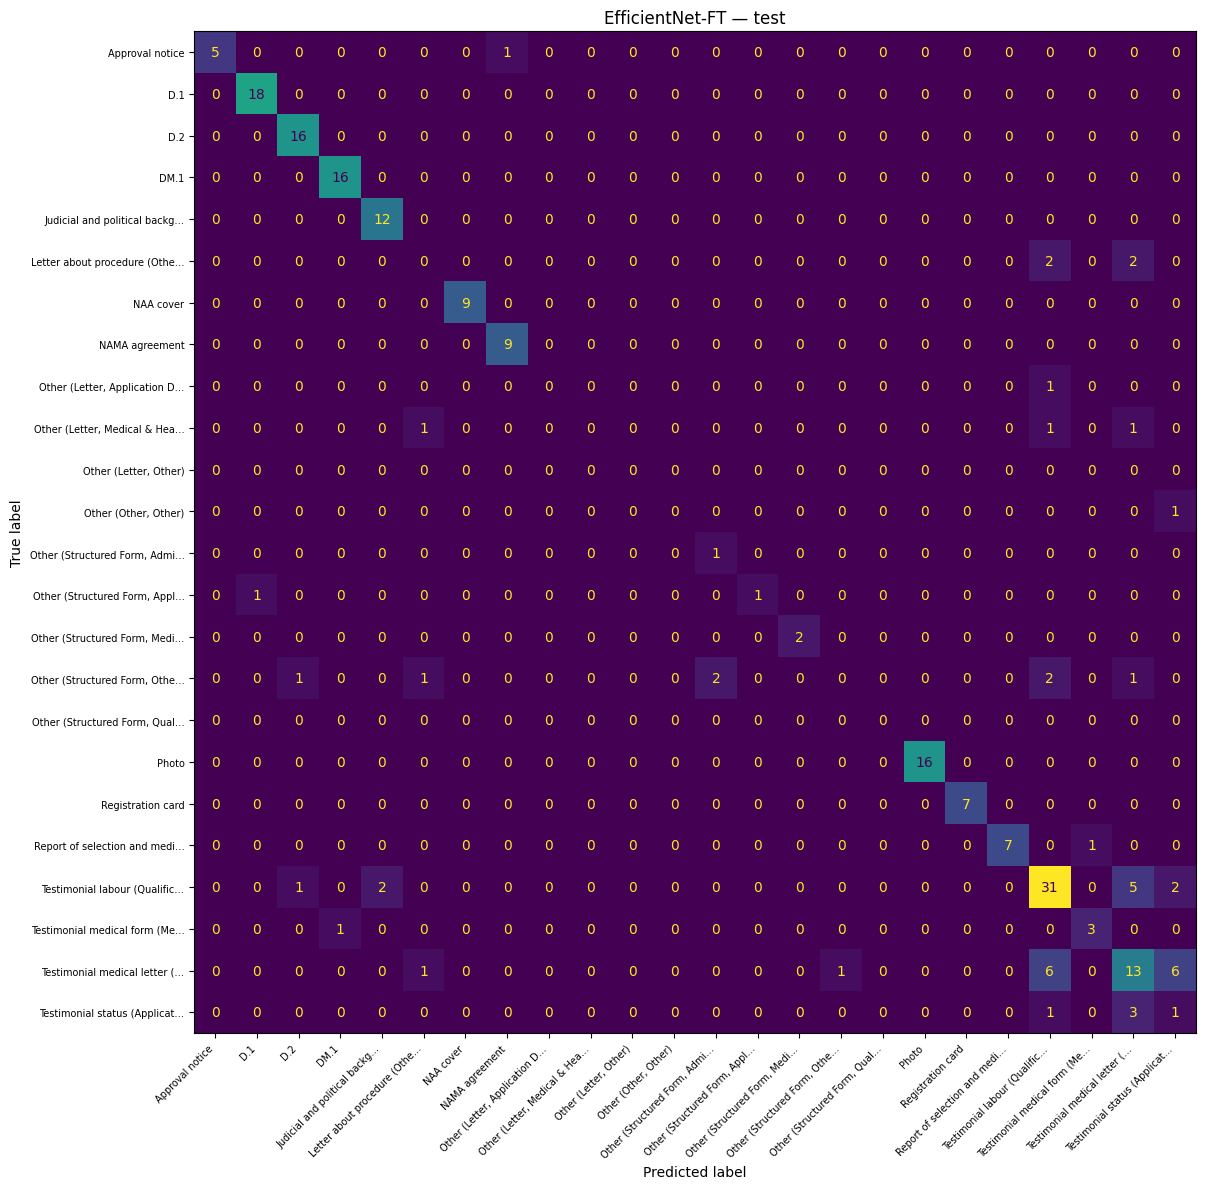

In [ ]:
eff_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
eff_ft.classifier[1] = nn.Linear(eff_ft.classifier[1].in_features, NUM_CLASSES)
eff_ft = eff_ft.to(DEVICE)

print('Training EfficientNet-B0 fine-tuned …')
eff_ft = train_finetune(eff_ft, tr_img_loader, va_img_loader, n_epochs=15)
pred_eff_ft_te, probs_eff_ft = predict_image_model(eff_ft, te_img_loader)

evaluate('EfficientNet-FT', y_va, predict_image_model(eff_ft, va_img_loader)[0], 'val')
results['EfficientNet-FT'] = evaluate('EfficientNet-FT', y_te, pred_eff_ft_te, 'test')
results['EfficientNet-FT']['preds_te'] = pred_eff_ft_te
results['EfficientNet-FT']['probs_te'] = probs_eff_ft


### 7e. LSTM + VGG-16

Each dossier is treated as a sequence of pages; a bidirectional LSTM processes the
VGG-16 feature sequence and predicts a label per page.


In [ ]:
class DossierSequenceDataset(Dataset):
    """Groups pages by dossier and returns per-page VGG features + labels as sequences."""
    def __init__(self, df: pd.DataFrame, X_vgg_all: np.ndarray):
        self.sequences = []
        for dos, grp in df.groupby('dossier'):
            grp = grp.sort_values('page_num')
            feats  = X_vgg_all[grp.index]
            labels = grp['label'].values
            self.sequences.append((feats, labels))

    def __len__(self): return len(self.sequences)

    def __getitem__(self, i):
        feats, labels = self.sequences[i]
        return (
            torch.tensor(feats,  dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
        )


def lstm_collate(batch):
    feats, labels = zip(*batch)
    return (
        torch.nn.utils.rnn.pad_sequence(feats,  batch_first=True),
        torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-1),
    )


class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)


lstm_tr = DossierSequenceDataset(df_tr, X_vgg)
lstm_va = DossierSequenceDataset(df_va, X_vgg)
lstm_te = DossierSequenceDataset(df_te, X_vgg)

tr_seq_loader = DataLoader(lstm_tr, batch_size=4, shuffle=True,  collate_fn=lstm_collate, num_workers=0)
va_seq_loader = DataLoader(lstm_va, batch_size=4, shuffle=False, collate_fn=lstm_collate, num_workers=0)
te_seq_loader = DataLoader(lstm_te, batch_size=4, shuffle=False, collate_fn=lstm_collate, num_workers=0)

lstm_model = LSTMClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw, ignore_index=-1)
opt  = optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)

best_f1, best_state = -1, None
for epoch in range(1, 16):
    lstm_model.train()
    for xb, yb in tr_seq_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = lstm_model(xb)
        loss   = crit(logits.view(-1, NUM_CLASSES), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        opt.step()

    lstm_model.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in va_seq_loader:
            logits = lstm_model(xb.to(DEVICE))
            mask   = (yb != -1)
            preds.extend(logits[mask].argmax(1).cpu().tolist())
    all_va = []
    for _, yb in va_seq_loader:
        mask = (yb != -1)
        all_va.extend(yb[mask].tolist())
    f1 = f1_score(all_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1   = f1
        best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_state)


  Epoch  1  val_macro_f1=0.2008
  Epoch  2  val_macro_f1=0.3409
  Epoch  3  val_macro_f1=0.4015
  Epoch  4  val_macro_f1=0.4261
  Epoch  5  val_macro_f1=0.4666
  Epoch  6  val_macro_f1=0.4653
  Epoch  7  val_macro_f1=0.5226
  Epoch  8  val_macro_f1=0.5487
  Epoch  9  val_macro_f1=0.5273
  Epoch 10  val_macro_f1=0.5956
  Epoch 11  val_macro_f1=0.5184
  Epoch 12  val_macro_f1=0.5351
  Epoch 13  val_macro_f1=0.5631
  Epoch 14  val_macro_f1=0.5962
  Epoch 15  val_macro_f1=0.5475


<All keys matched successfully>


── LSTM-VGG16 [test] ──
  Accuracy: 0.7302  |  Macro-F1: 0.5187
                               precision    recall  f1-score   support

              Approval notice       0.71      0.83      0.77         6
                          D.1       0.86      1.00      0.92        18
                          D.2       0.88      0.88      0.88        16
                         DM.1       0.83      0.94      0.88        16
Judicial and political backg…       0.80      1.00      0.89        12
Letter about procedure (Othe…       0.50      0.25      0.33         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.69      1.00      0.82         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (Stru

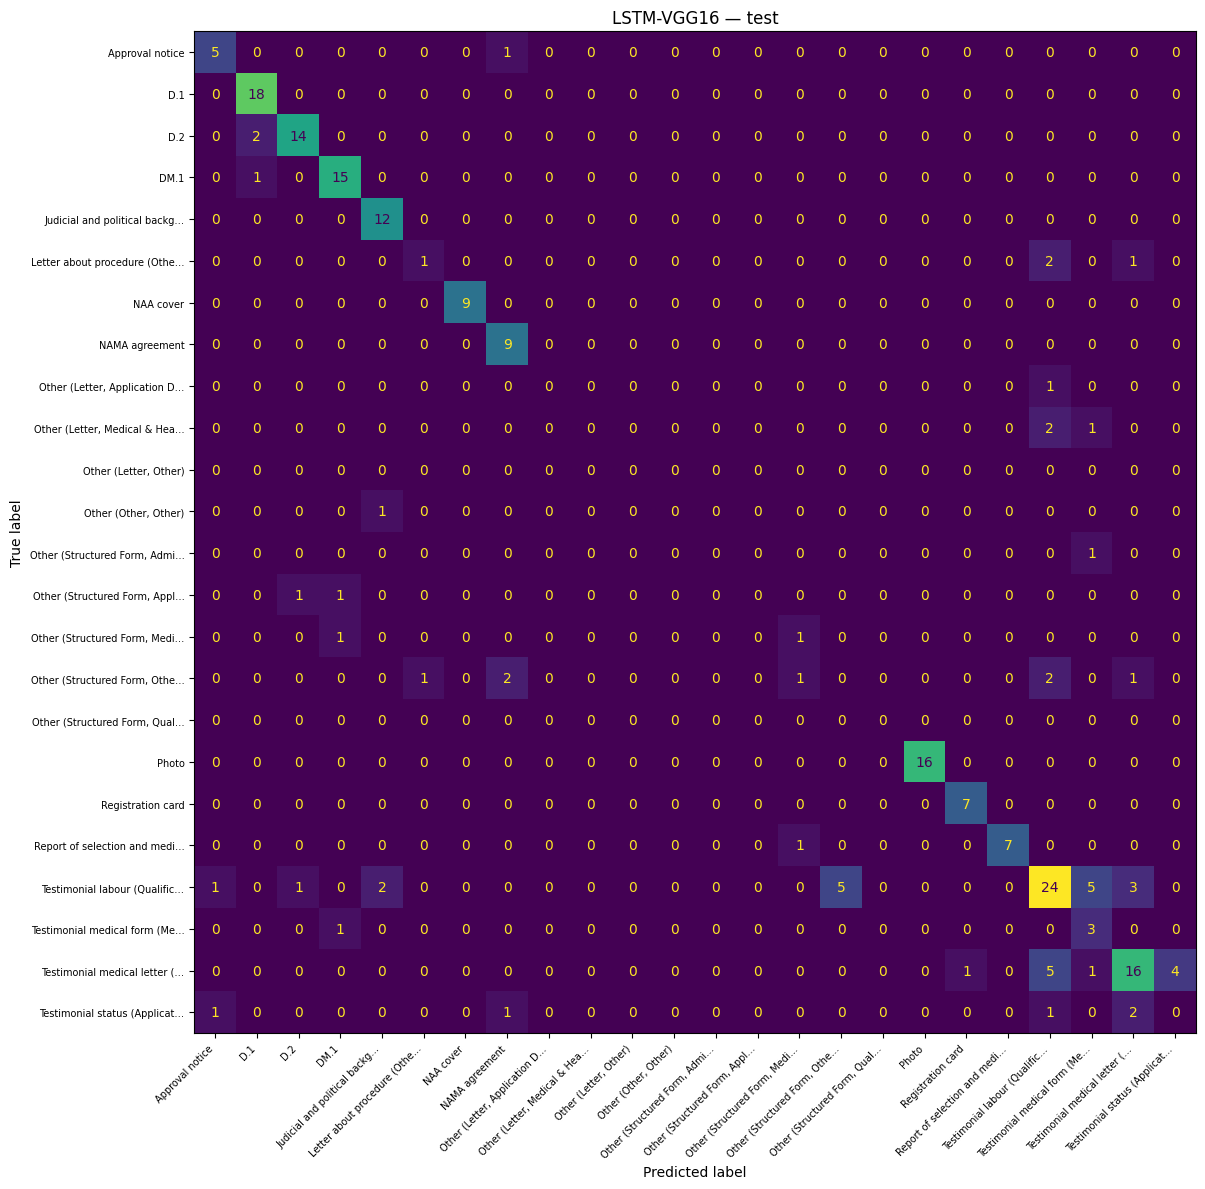

In [ ]:
lstm_model.eval()
pred_lstm_te, all_te = [], []
with torch.no_grad():
    for xb, yb in te_seq_loader:
        logits = lstm_model(xb.to(DEVICE))
        mask   = (yb != -1)
        pred_lstm_te.extend(logits[mask].argmax(1).cpu().tolist())
        all_te.extend(yb[mask].tolist())

pred_lstm_te = np.array(pred_lstm_te)
results['LSTM-VGG16'] = evaluate('LSTM-VGG16', np.array(all_te), pred_lstm_te, 'test')
results['LSTM-VGG16']['preds_te'] = pred_lstm_te


---
## 8. Text-Only Models (Qwen-7B Transcriptions)

### 8a. KNN + BERT

k= 3  val macro-F1=0.6218
k= 5  val macro-F1=0.5923
k= 7  val macro-F1=0.6275
k=11  val macro-F1=0.5449
k=15  val macro-F1=0.5294

Best k=7

── KNN-BERT [val] ──
  Accuracy: 0.7590  |  Macro-F1: 0.6275
                               precision    recall  f1-score   support

              Approval notice       0.88      1.00      0.93        14
                          D.1       0.80      1.00      0.89        16
                          D.2       1.00      0.92      0.96        25
                         DM.1       0.96      1.00      0.98        22
Judicial and political backg…       0.58      1.00      0.73        22
Letter about procedure (Othe…       0.59      0.58      0.59        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.93      1.00      0.96        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (

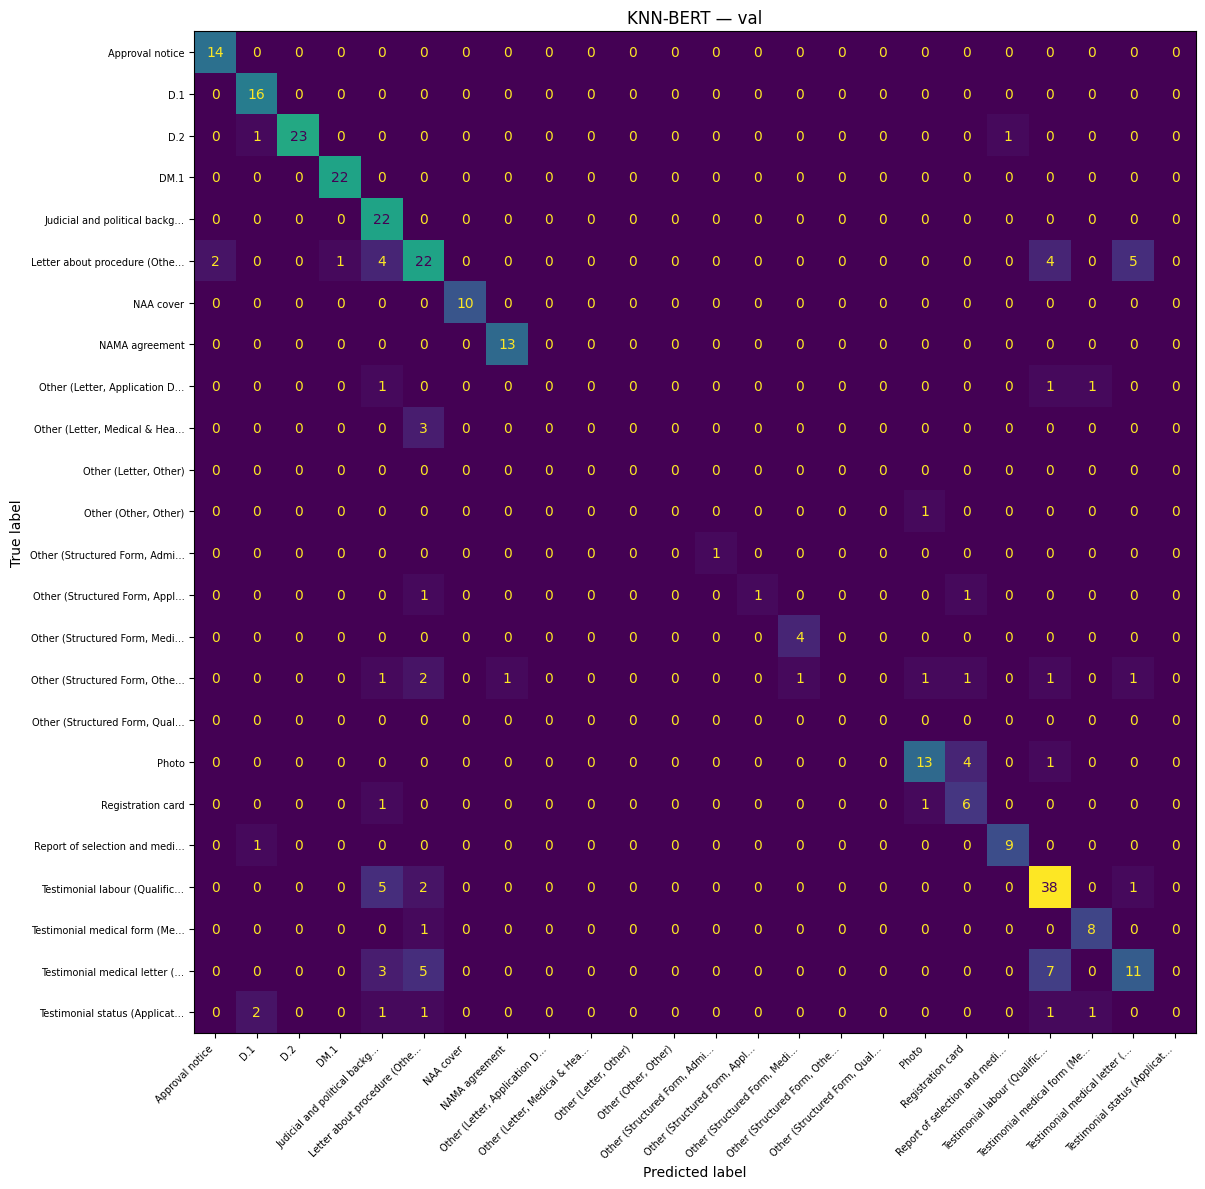


── KNN-BERT [test] ──
  Accuracy: 0.7721  |  Macro-F1: 0.5656
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       0.90      1.00      0.95        18
                          D.2       0.89      1.00      0.94        16
                         DM.1       0.89      1.00      0.94        16
Judicial and political backg…       0.50      1.00      0.67        12
Letter about procedure (Othe…       0.30      0.75      0.43         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.64      1.00      0.78         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (Struct

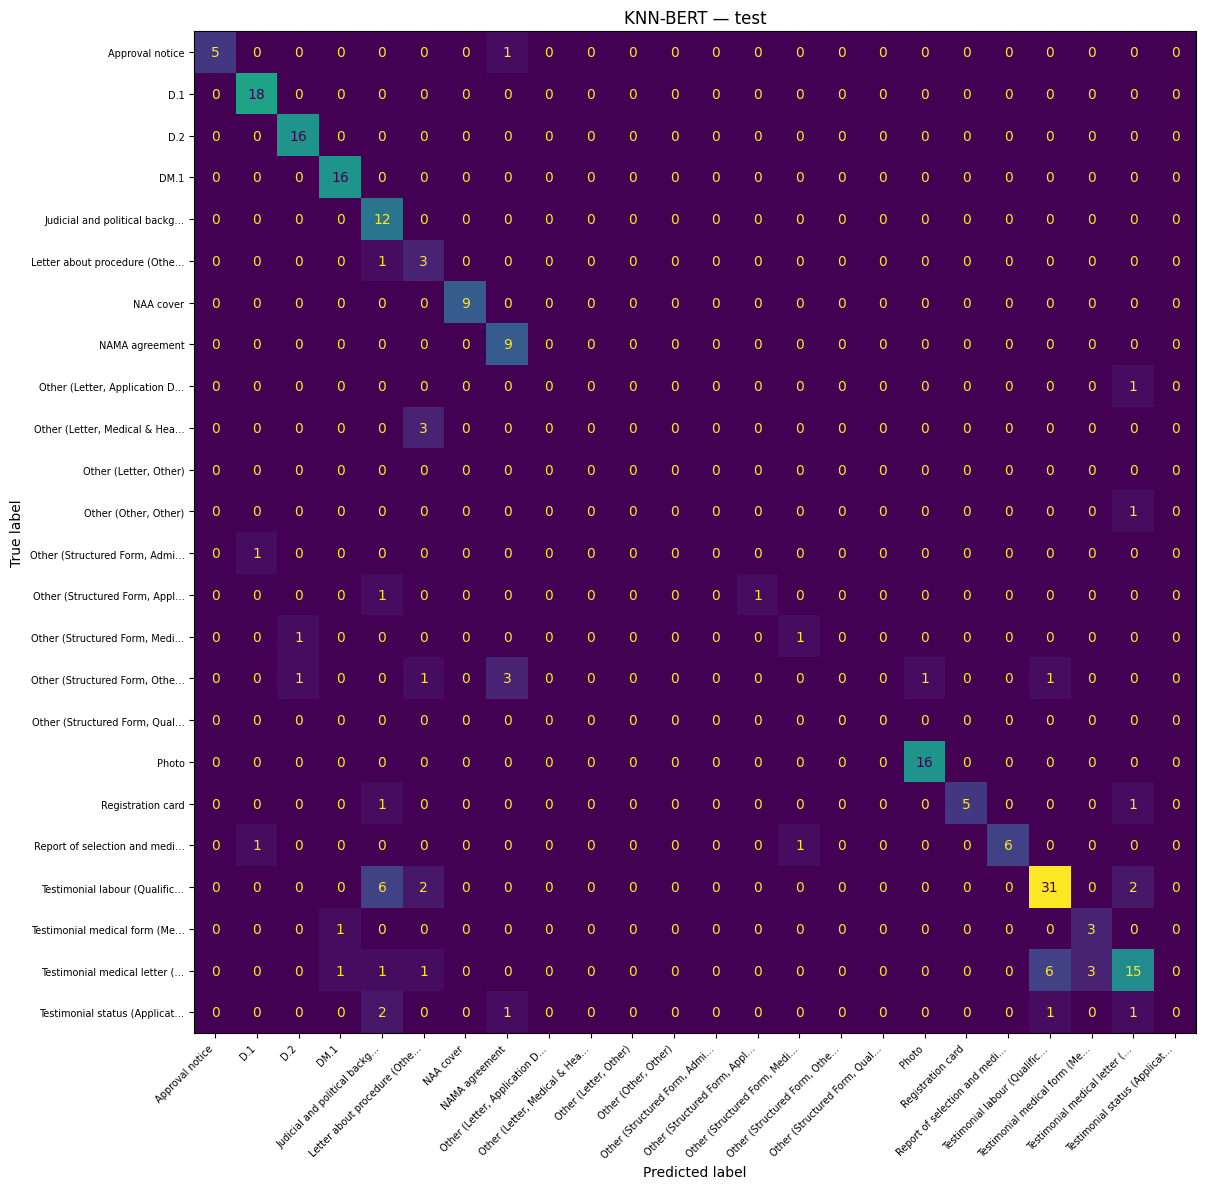

In [ ]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_bert_tr_n, y_tr)
    f1 = f1_score(y_va, knn.predict(X_bert_va_n), average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_bert = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)
pred_knn_bert_te = knn_bert.predict(X_bert_te_n)

evaluate('KNN-BERT', y_va, knn_bert.predict(X_bert_va_n), 'val')
results['KNN-BERT'] = evaluate('KNN-BERT', y_te, pred_knn_bert_te, 'test')
results['KNN-BERT']['preds_te'] = pred_knn_bert_te


### 8b. XGBoost + BERT


── XGBoost-BERT [val] ──
  Accuracy: 0.8404  |  Macro-F1: 0.6782
                               precision    recall  f1-score   support

              Approval notice       0.93      1.00      0.97        14
                          D.1       0.84      1.00      0.91        16
                          D.2       0.96      0.92      0.94        25
                         DM.1       1.00      1.00      1.00        22
Judicial and political backg…       0.88      1.00      0.94        22
Letter about procedure (Othe…       0.70      0.79      0.74        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.93      1.00      0.96        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       1.00      1.00      1.00         1
Other (Str

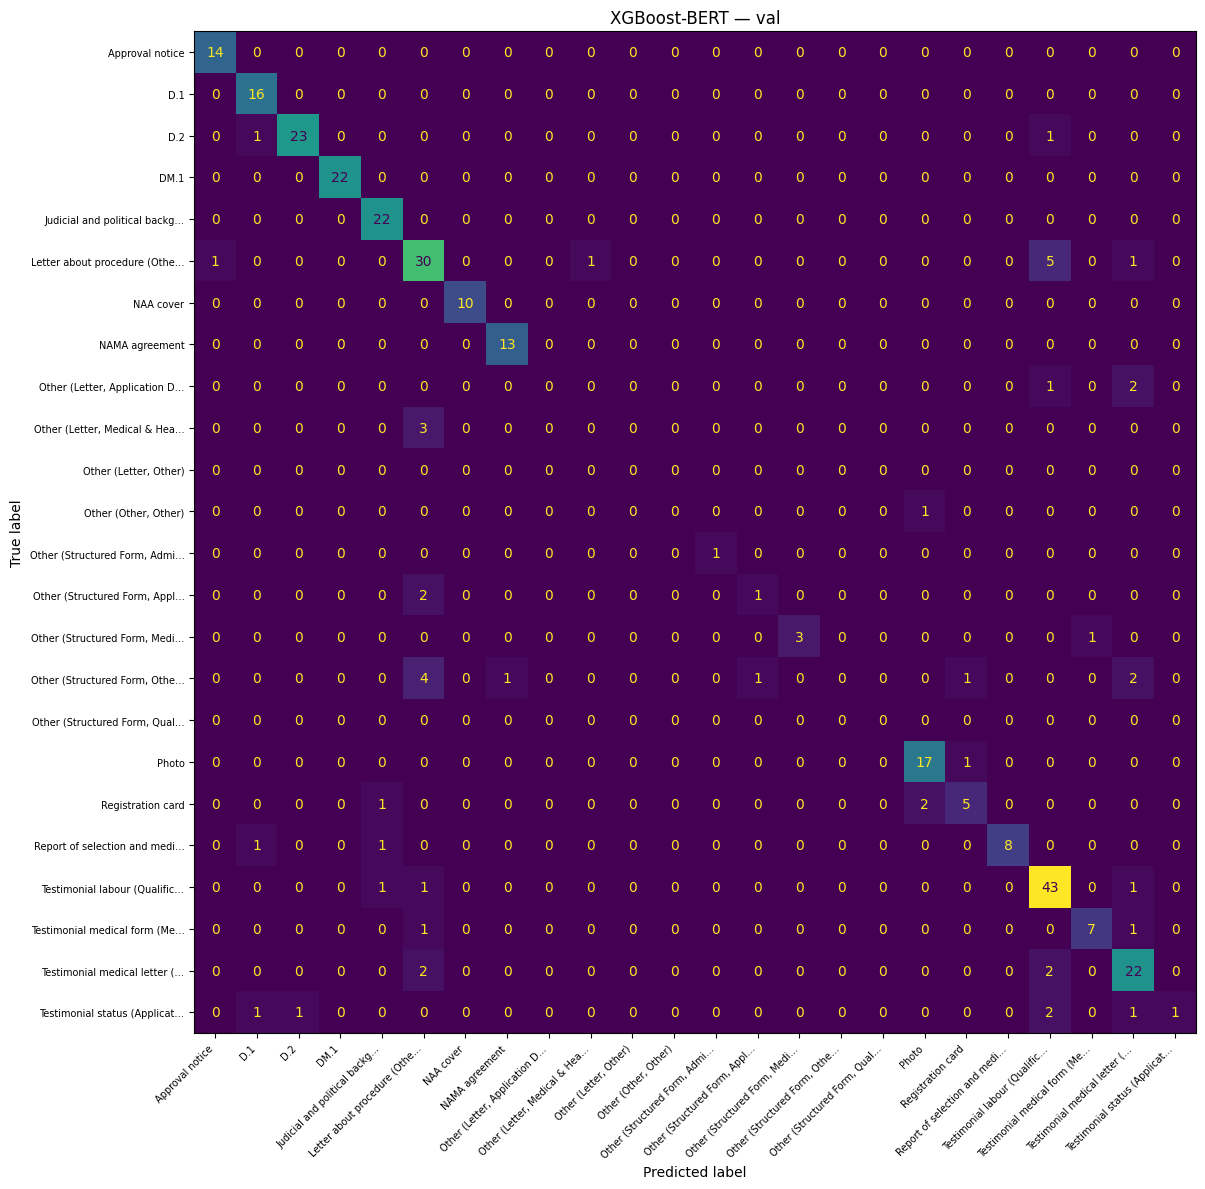


── XGBoost-BERT [test] ──
  Accuracy: 0.8791  |  Macro-F1: 0.6730
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.86      1.00      0.92        12
Letter about procedure (Othe…       0.50      1.00      0.67         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.75      1.00      0.86         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (St

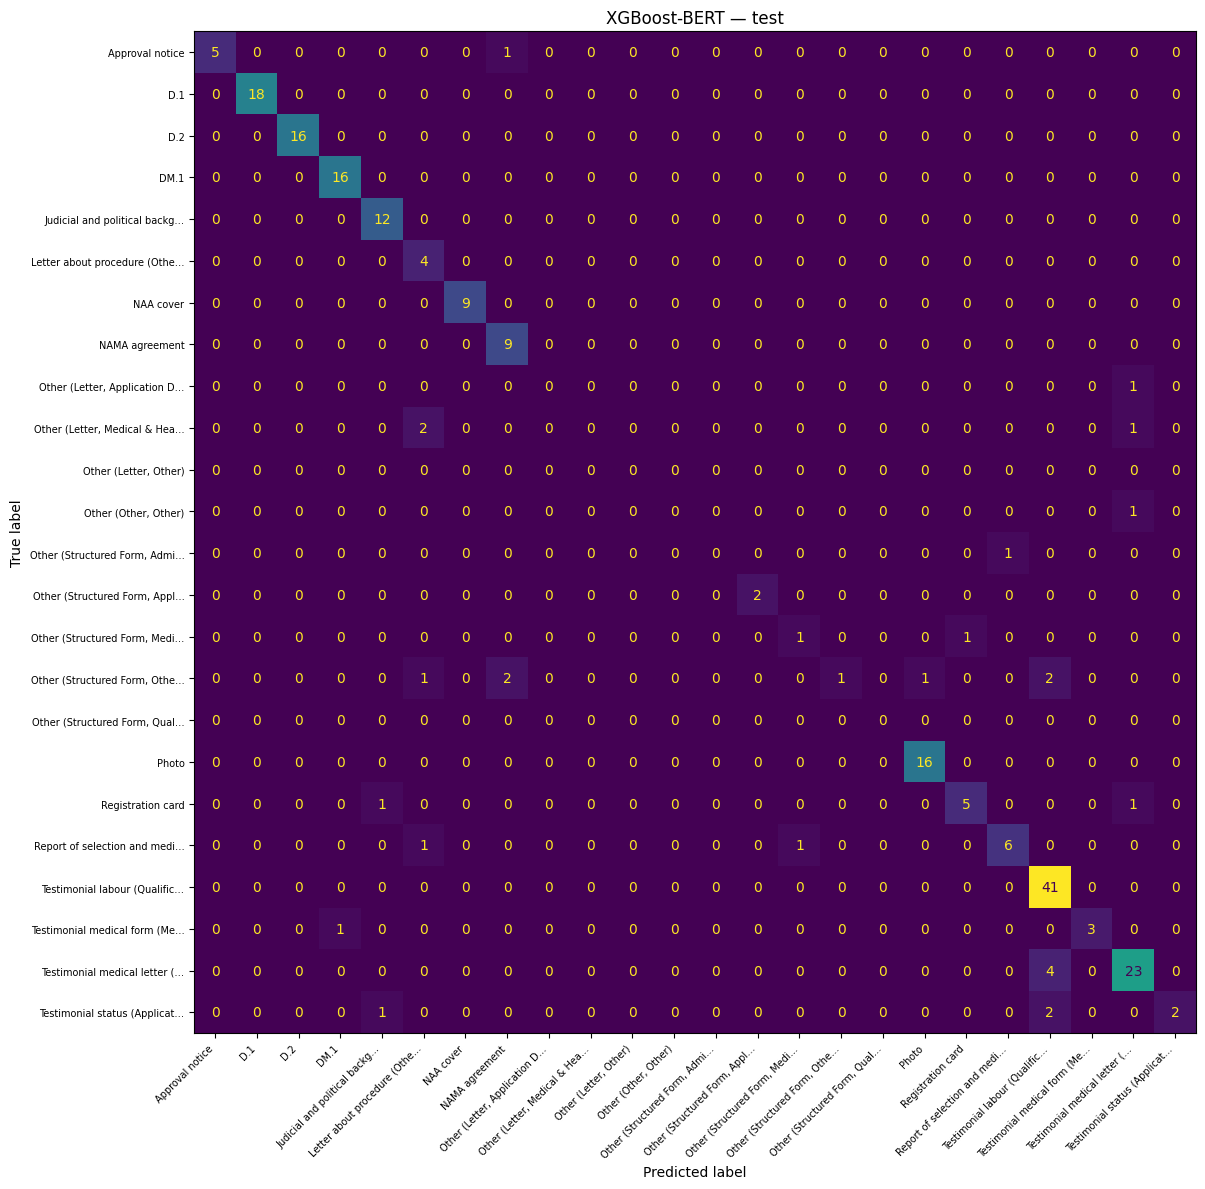

In [ ]:
xgb_bert = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_bert.fit(X_bert_tr, y_tr, eval_set=[(X_bert_va, y_va)], verbose=False)
pred_xgb_bert_te = xgb_bert.predict(X_bert_te)

evaluate('XGBoost-BERT', y_va, xgb_bert.predict(X_bert_va), 'val')
results['XGBoost-BERT'] = evaluate('XGBoost-BERT', y_te, pred_xgb_bert_te, 'test')
results['XGBoost-BERT']['preds_te'] = pred_xgb_bert_te


### 8c. TEXT-CNN (frozen BERT backbone + 1D-CNN)

Frozen BERT token embeddings → multi-scale 1D convolutions → max-over-time pooling → linear head.


In [ ]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool → MLP."""
    def __init__(self, bert_model, embed_dim=768, num_filters=128,
                 filter_sizes=(2, 3, 4), num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.bert  = bert_model
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb = out.last_hidden_state    # (B, T, E)
        x = emb.transpose(1, 2)            # (B, E, T)
        pooled = [
            F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
            for conv in self.convs
        ]
        return self.fc(self.drop(torch.cat(pooled, dim=1)))


tcnn_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base  = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_loader = DataLoader(TextDataset(df_tr, tcnn_tokenizer), batch_size=16, shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(TextDataset(df_va, tcnn_tokenizer), batch_size=32, shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(TextDataset(df_te, tcnn_tokenizer), batch_size=32, shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)


Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.6261
  Epoch  2  val_macro_f1=0.7031
  Epoch  3  val_macro_f1=0.6750
  Epoch  4  val_macro_f1=0.7173
  Epoch  5  val_macro_f1=0.6912
  Epoch  6  val_macro_f1=0.7192
  Epoch  7  val_macro_f1=0.7258
  Epoch  8  val_macro_f1=0.6997
  Epoch  9  val_macro_f1=0.7468
  Epoch 10  val_macro_f1=0.7520
  Epoch 11  val_macro_f1=0.7150
  Epoch 12  val_macro_f1=0.7288
  Epoch 13  val_macro_f1=0.7157
  Epoch 14  val_macro_f1=0.7528
  Epoch 15  val_macro_f1=0.7191

── TEXT-CNN [val] ──
  Accuracy: 0.9121  |  Macro-F1: 0.7528
                               precision    recall  f1-score   support

              Approval notice       1.00      1.00      1.00        14
                          D.1       0.94      1.00      0.97        16
                          D.2       1.00      0.96      0.98        25
                         DM.1       0.96      1.00      0.98        22
Judicial and political backg…       0.96      1.00      0.98        22
Letter abou

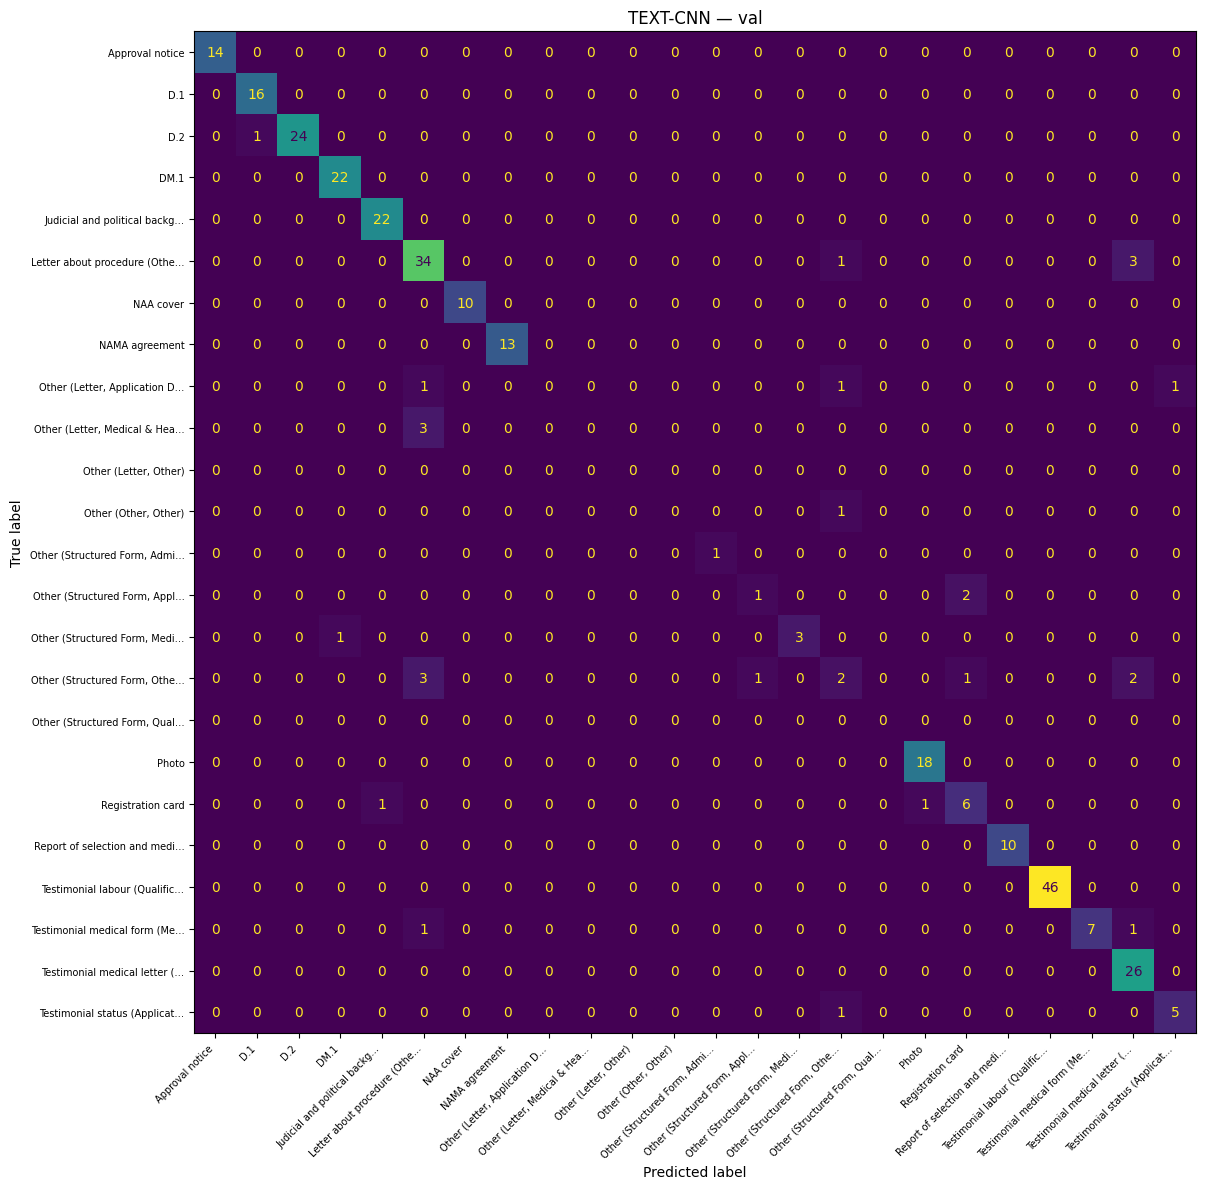


── TEXT-CNN [test] ──
  Accuracy: 0.9116  |  Macro-F1: 0.7566
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       1.00      1.00      1.00        12
Letter about procedure (Othe…       0.50      1.00      0.67         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.82      1.00      0.90         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       1.00      1.00      1.00         1
Other (Struct

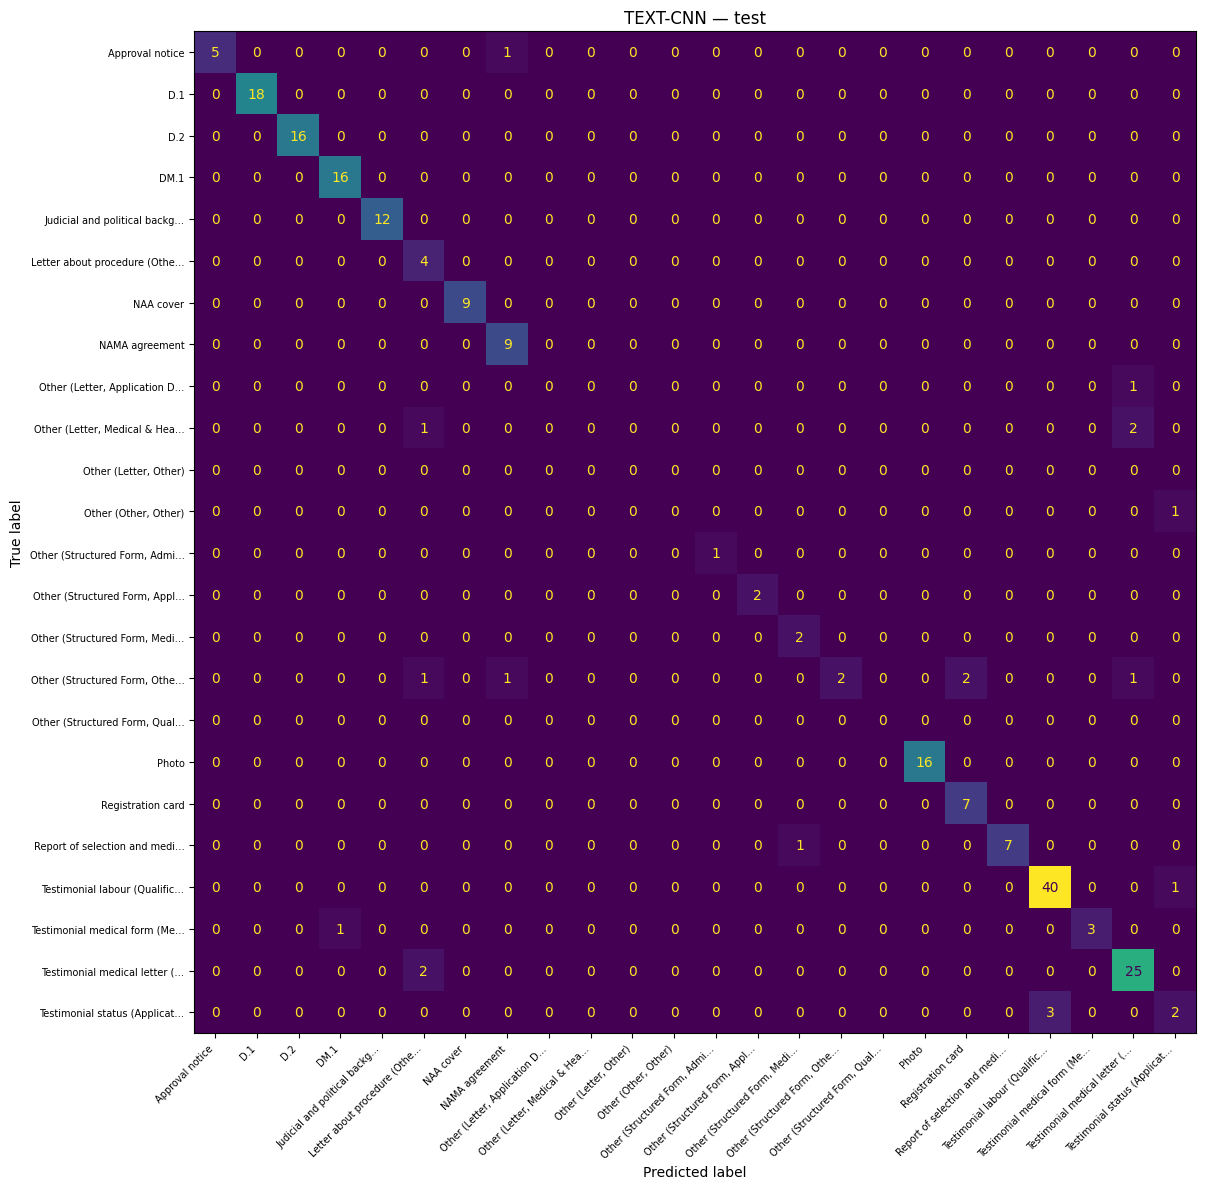

In [ ]:
def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(ids, mask), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1   = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader, n_epochs=15)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)

evaluate('TEXT-CNN', y_va, predict_text_model(tcnn_model, tcnn_va_loader)[0], 'val')
results['TEXT-CNN'] = evaluate('TEXT-CNN', y_te, pred_tcnn_te, 'test')
results['TEXT-CNN']['preds_te'] = pred_tcnn_te
results['TEXT-CNN']['probs_te'] = probs_tcnn


### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,500,696
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.5941
  Epoch  2  val_macro_f1=0.6886
  Epoch  3  val_macro_f1=0.6837
  Epoch  4  val_macro_f1=0.6934
  Epoch  5  val_macro_f1=0.7192
  Epoch  6  val_macro_f1=0.7045
  Epoch  7  val_macro_f1=0.7220
  Epoch  8  val_macro_f1=0.7344
  Epoch  9  val_macro_f1=0.7290
  Epoch 10  val_macro_f1=0.7264

── BERT Fine-Tuned [val] ──
  Accuracy: 0.8925  |  Macro-F1: 0.7344
                               precision    recall  f1-score   support

              Approval notice       1.00      0.93      0.96        14
                          D.1       0.94      1.00      0.97        16
                          D.2       0.96      0.96      0.96        25
                         DM.1       1.00      1.00      1.00        22
Judicial and political backg…       0.96      1.00      0.98        22
Letter about procedure (Othe…       0.71      0.84      0.77        38
                    NAA cover       1.00     

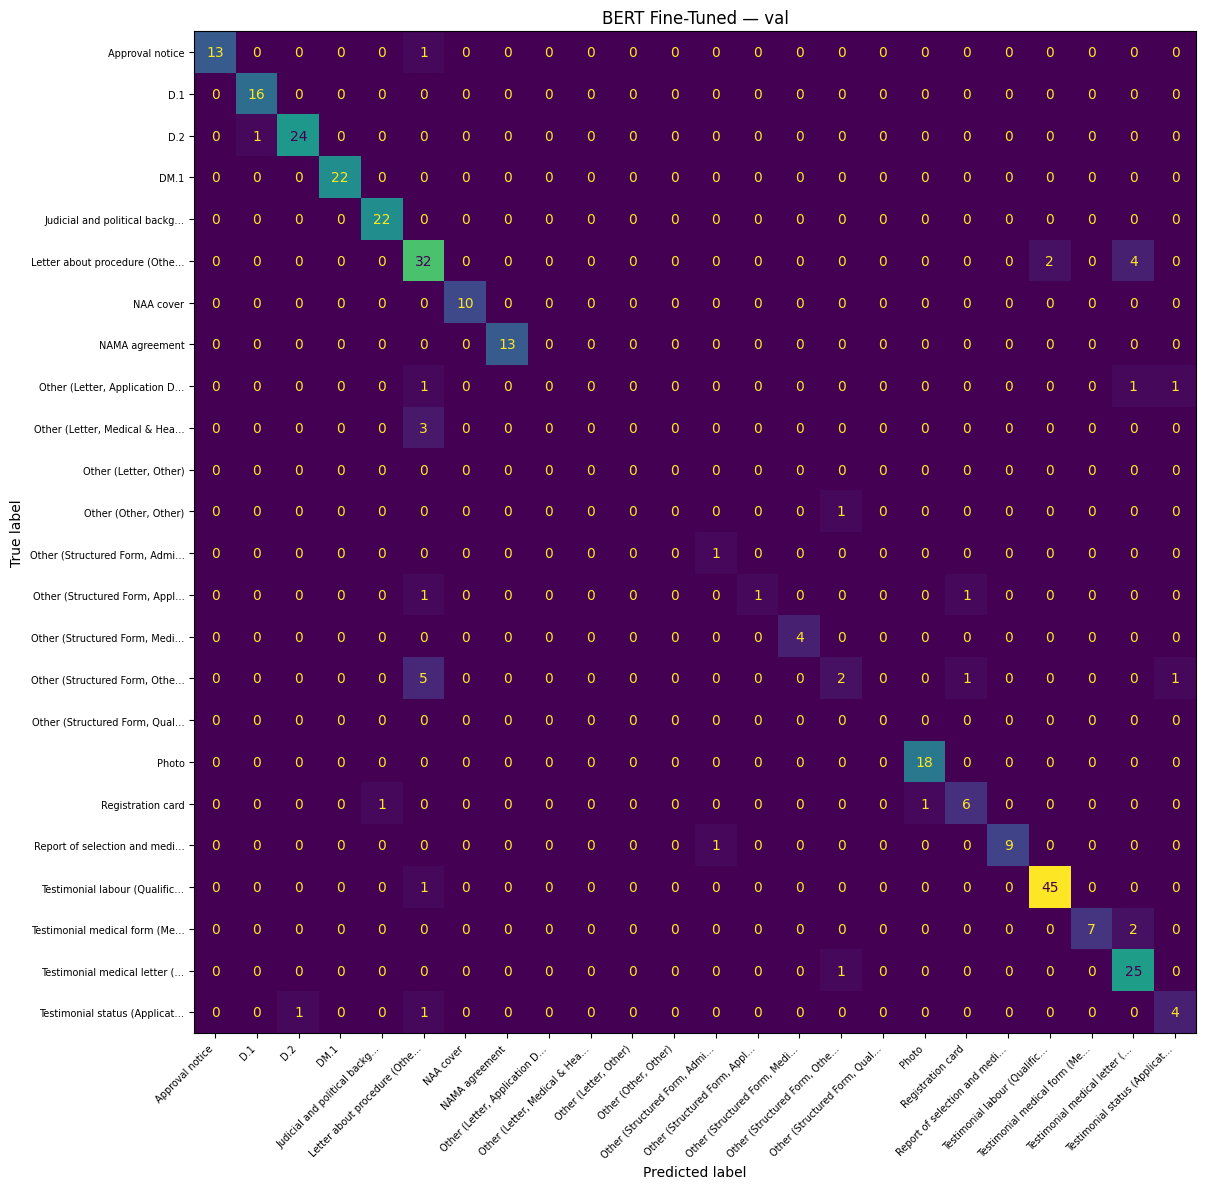


── BERT Fine-Tuned [test] ──
  Accuracy: 0.9209  |  Macro-F1: 0.7720
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.92      1.00      0.96        12
Letter about procedure (Othe…       0.50      0.75      0.60         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.82      1.00      0.90         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       1.00      1.00      1.00         1
Other 

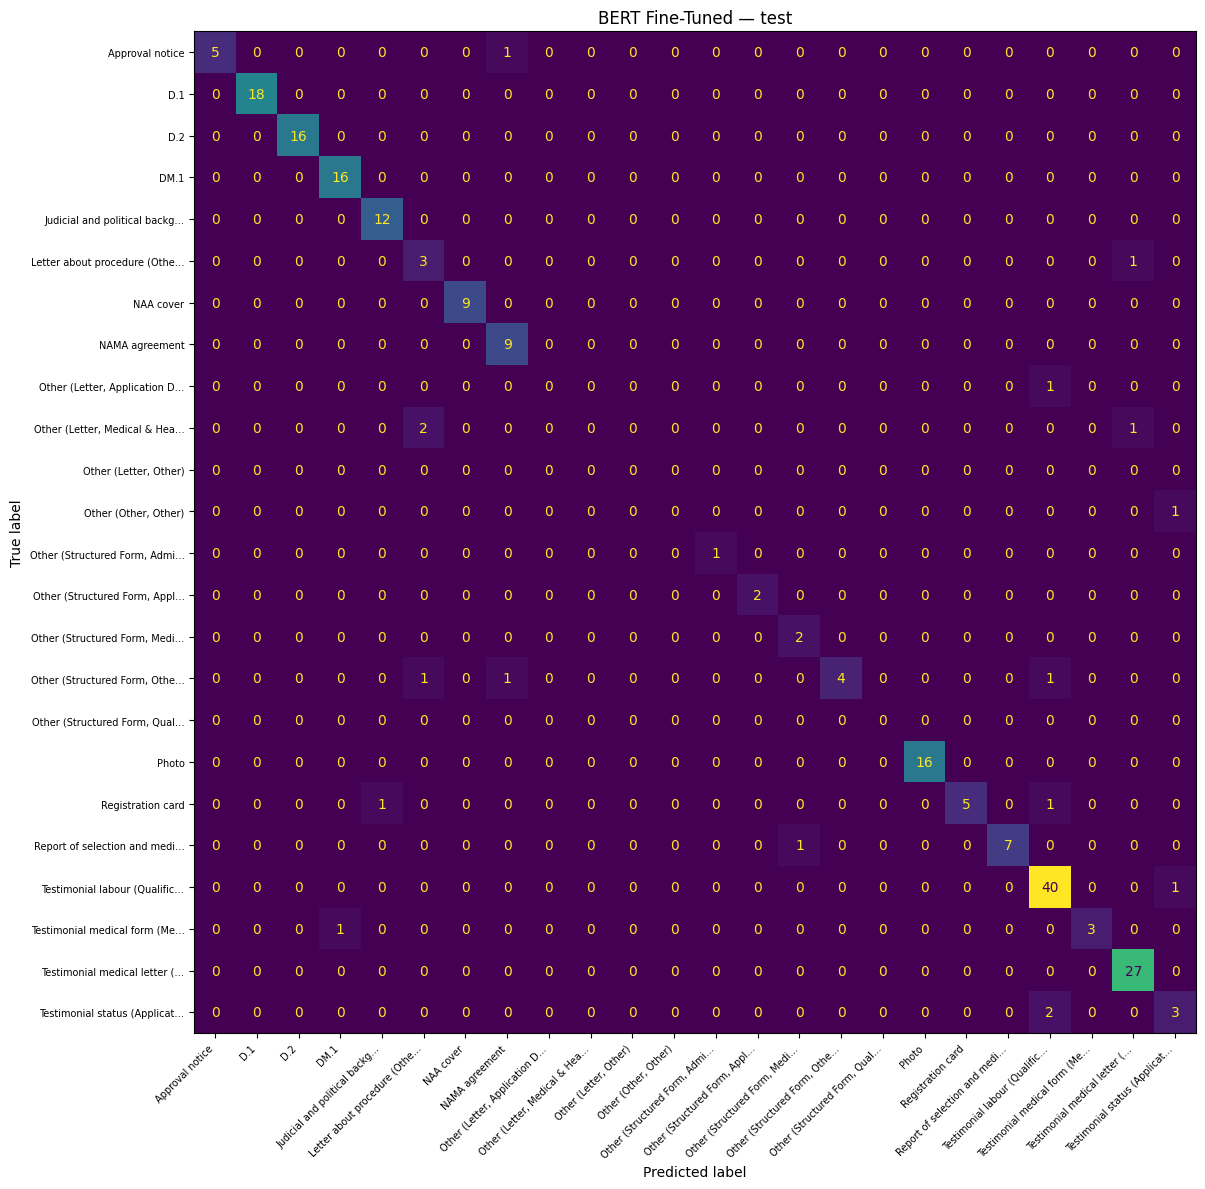

In [ ]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_loader = DataLoader(TextDataset(df_tr, bert_ft_tokenizer), batch_size=8,  shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(TextDataset(df_va, bert_ft_tokenizer), batch_size=16, shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(TextDataset(df_te, bert_ft_tokenizer), batch_size=16, shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)

pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
evaluate('BERT Fine-Tuned', y_va, predict_text_model(bert_clf, bert_ft_va_loader)[0], 'val')
results['BERT-FT'] = evaluate('BERT Fine-Tuned', y_te, pred_bert_ft_te, 'test')
results['BERT-FT']['preds_te'] = pred_bert_ft_te
results['BERT-FT']['probs_te'] = probs_bert_ft


---
## 9. Fusion Models

### 9a. KNN-Ensemble (VGG-16 + BERT concatenated features)

k= 3  val macro-F1=0.5495
k= 5  val macro-F1=0.5398
k= 7  val macro-F1=0.5400
k=11  val macro-F1=0.5398
k=15  val macro-F1=0.5243

Best k=3

── KNN-Ensemble [val] ──
  Accuracy: 0.7394  |  Macro-F1: 0.5495
                               precision    recall  f1-score   support

              Approval notice       0.82      1.00      0.90        14
                          D.1       0.73      1.00      0.84        16
                          D.2       0.92      0.96      0.94        25
                         DM.1       0.79      1.00      0.88        22
Judicial and political backg…       0.76      1.00      0.86        22
Letter about procedure (Othe…       0.75      0.32      0.44        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.93      1.00      0.96        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Oth

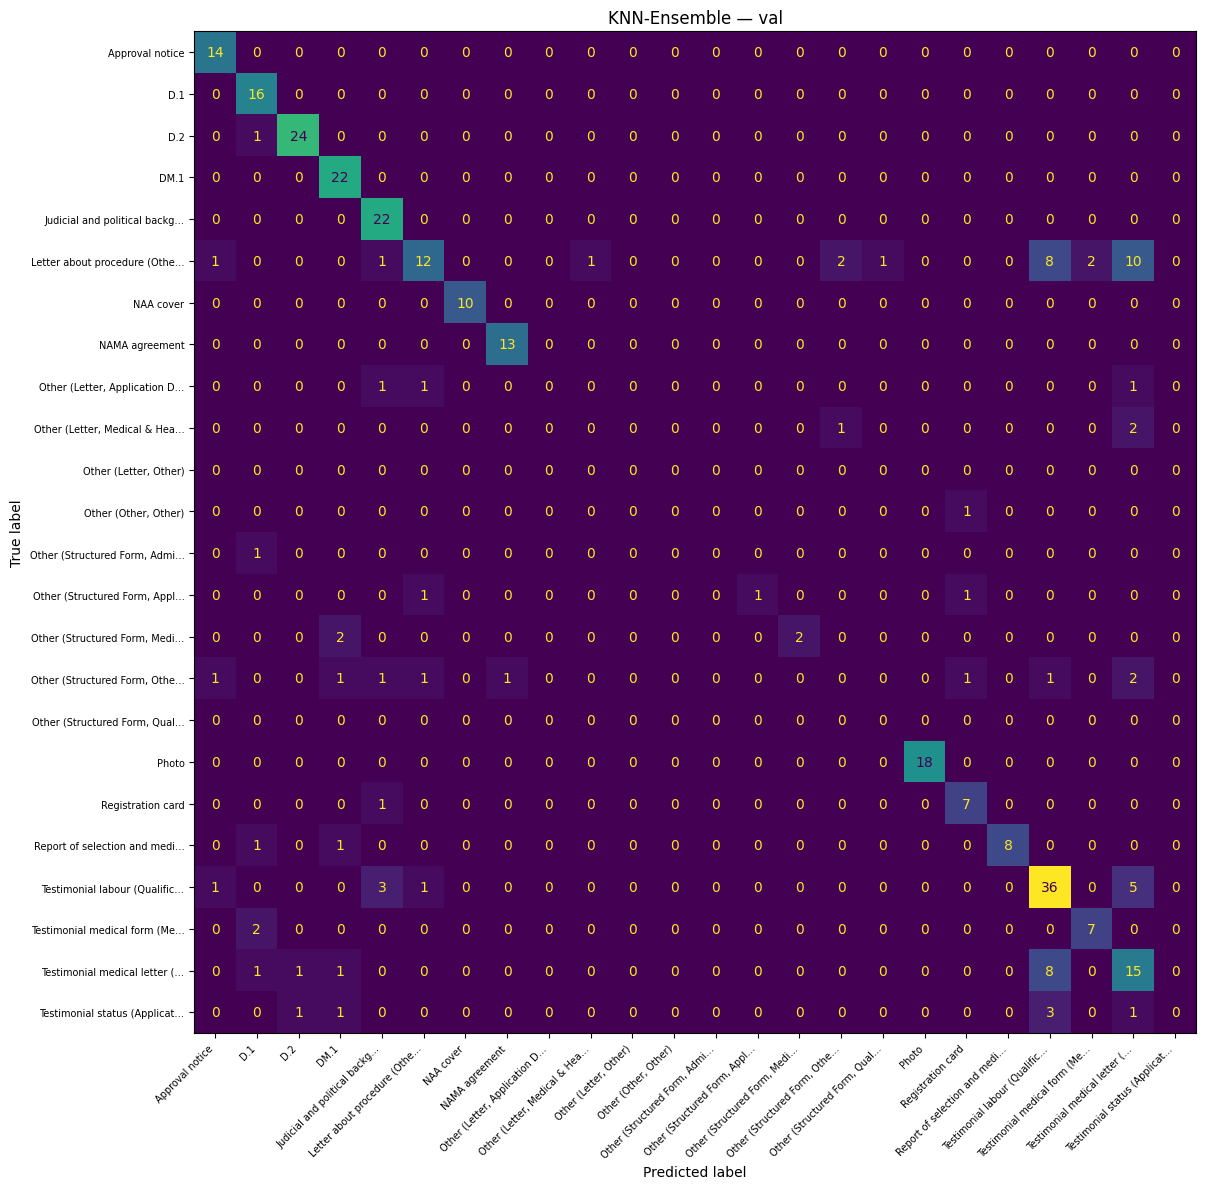


── KNN-Ensemble [test] ──
  Accuracy: 0.7535  |  Macro-F1: 0.5039
                               precision    recall  f1-score   support

              Approval notice       0.62      0.83      0.71         6
                          D.1       0.78      1.00      0.88        18
                          D.2       0.94      1.00      0.97        16
                         DM.1       0.80      1.00      0.89        16
Judicial and political backg…       0.75      1.00      0.86        12
Letter about procedure (Othe…       0.12      0.25      0.17         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.75      1.00      0.86         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other (St

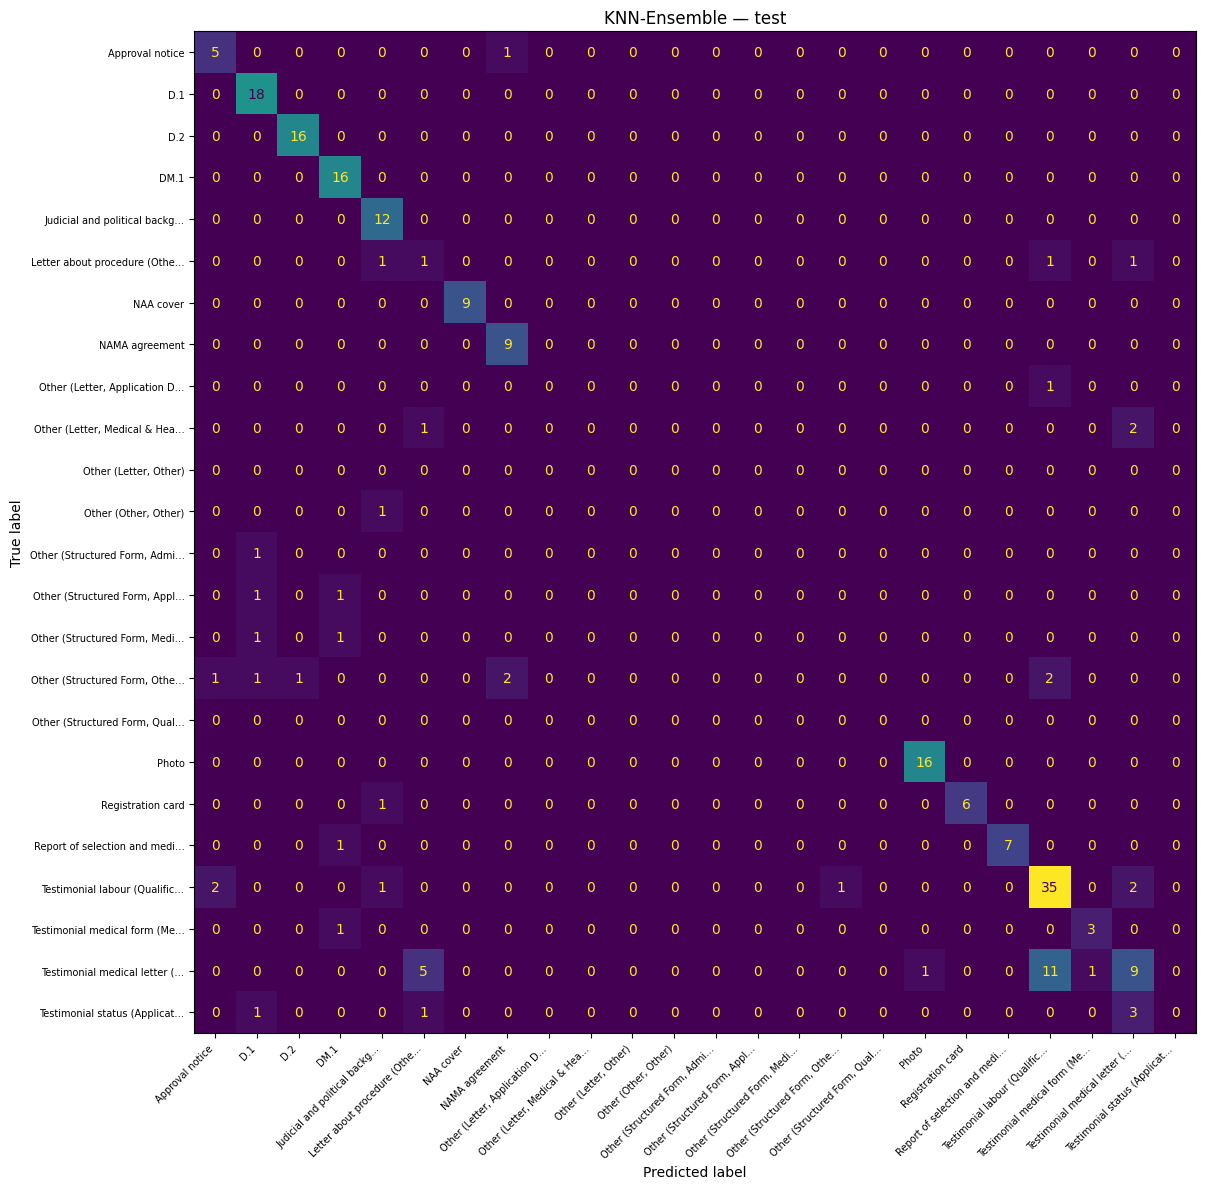

In [ ]:
X_ens_tr = np.hstack([normalize(X_vgg_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_vgg_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_vgg_te), normalize(X_bert_te)])

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_ens_tr, y_tr)
    f1 = f1_score(y_va, knn.predict(X_ens_va), average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_ens = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)
pred_knn_ens_te = knn_ens.predict(X_ens_te)

evaluate('KNN-Ensemble', y_va, knn_ens.predict(X_ens_va), 'val')
results['KNN-Ensemble'] = evaluate('KNN-Ensemble', y_te, pred_knn_ens_te, 'test')
results['KNN-Ensemble']['preds_te'] = pred_knn_ens_te


### 9b. XGBoost-Ensemble (VGG-16 + BERT concatenated features)


── XGBoost-Ensemble [val] ──
  Accuracy: 0.8241  |  Macro-F1: 0.6167
                               precision    recall  f1-score   support

              Approval notice       0.82      1.00      0.90        14
                          D.1       0.89      1.00      0.94        16
                          D.2       0.96      0.92      0.94        25
                         DM.1       0.88      1.00      0.94        22
Judicial and political backg…       0.92      1.00      0.96        22
Letter about procedure (Othe…       0.92      0.63      0.75        38
                    NAA cover       1.00      1.00      1.00        10
               NAMA agreement       0.87      1.00      0.93        13
Other (Letter, Application D…       0.00      0.00      0.00         3
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.33      1.00      0.50         1
Other 

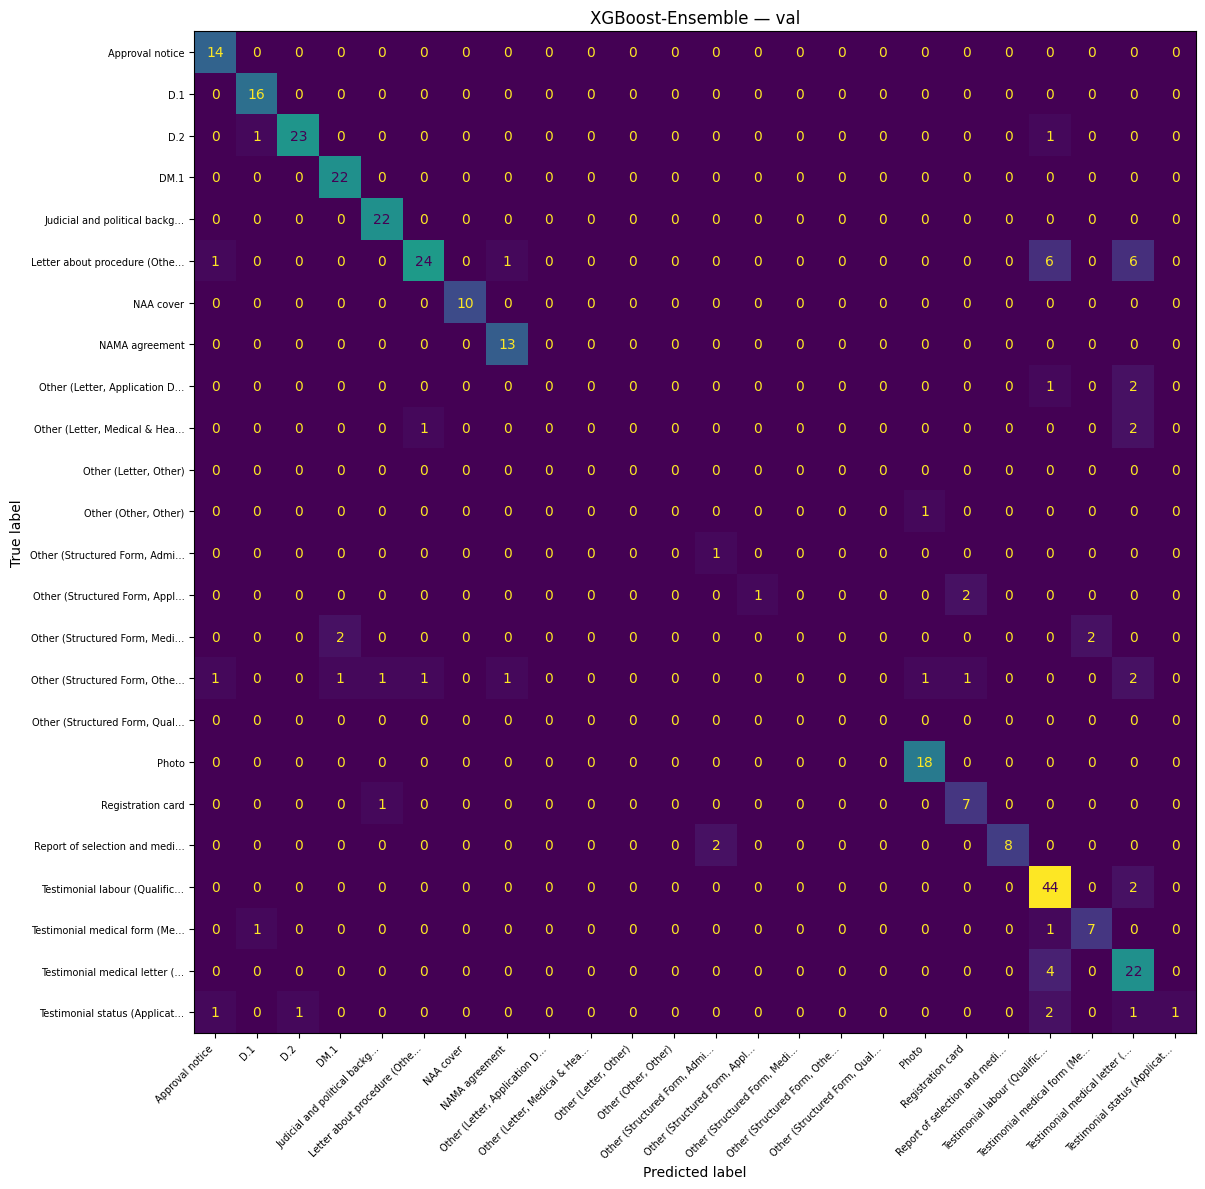


── XGBoost-Ensemble [test] ──
  Accuracy: 0.8651  |  Macro-F1: 0.5795
                               precision    recall  f1-score   support

              Approval notice       0.71      0.83      0.77         6
                          D.1       0.90      1.00      0.95        18
                          D.2       0.94      1.00      0.97        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.86      1.00      0.92        12
Letter about procedure (Othe…       0.33      0.50      0.40         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.90      1.00      0.95         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.00      0.00      0.00         1
Other

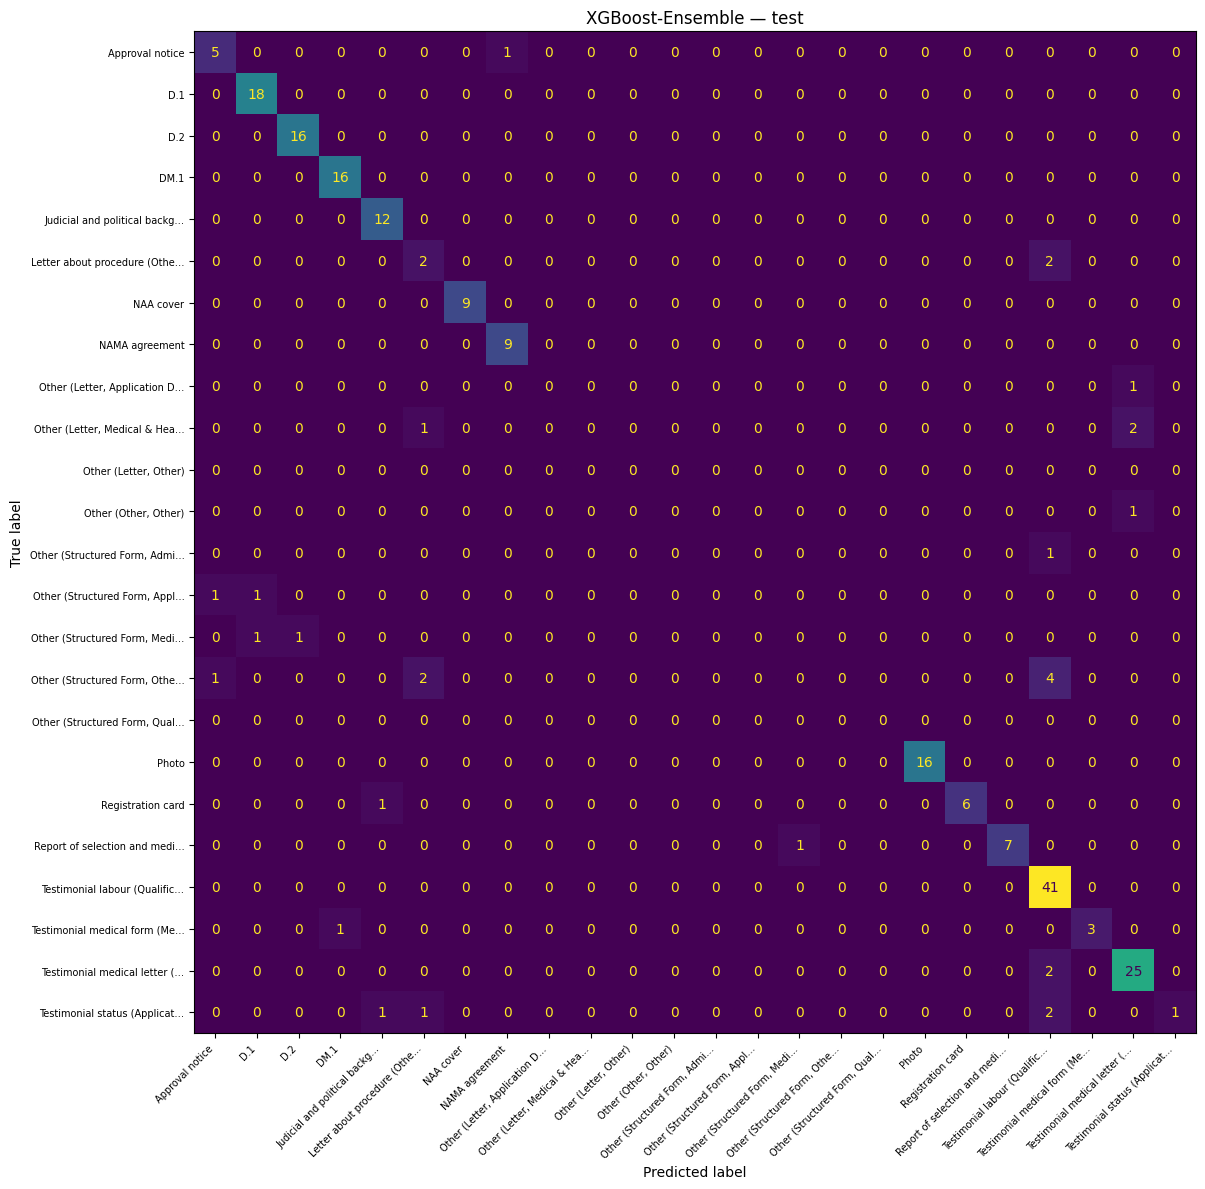

In [ ]:
xgb_ens = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0,
    n_jobs=-1,
)
xgb_ens.fit(X_ens_tr, y_tr, eval_set=[(X_ens_va, y_va)], verbose=False)
pred_xgb_ens_te = xgb_ens.predict(X_ens_te)

evaluate('XGBoost-Ensemble', y_va, xgb_ens.predict(X_ens_va), 'val')
results['XGBoost-Ensemble'] = evaluate('XGBoost-Ensemble', y_te, pred_xgb_ens_te, 'test')
results['XGBoost-Ensemble']['preds_te'] = pred_xgb_ens_te


### 9c. Early Fusion — EfficientNet-B0 + BERT → MLP

Concatenates frozen EfficientNet-B0 features with frozen BERT [CLS] features,
then trains a lightweight MLP head.


  Epoch  1  val_macro_f1=0.5256
  Epoch  2  val_macro_f1=0.6449
  Epoch  3  val_macro_f1=0.6456
  Epoch  4  val_macro_f1=0.6440
  Epoch  5  val_macro_f1=0.6845
  Epoch  6  val_macro_f1=0.6419
  Epoch  7  val_macro_f1=0.6654
  Epoch  8  val_macro_f1=0.6393
  Epoch  9  val_macro_f1=0.6841
  Epoch 10  val_macro_f1=0.6463
  Epoch 11  val_macro_f1=0.6613
  Epoch 12  val_macro_f1=0.6882
  Epoch 13  val_macro_f1=0.6765
  Epoch 14  val_macro_f1=0.6680
  Epoch 15  val_macro_f1=0.6352

── Early-Fusion [val] ──
  Accuracy: 0.8664  |  Macro-F1: 0.6882
                               precision    recall  f1-score   support

              Approval notice       0.78      1.00      0.88        14
                          D.1       0.94      1.00      0.97        16
                          D.2       1.00      0.96      0.98        25
                         DM.1       1.00      1.00      1.00        22
Judicial and political backg…       0.96      1.00      0.98        22
Letter about procedure (Oth

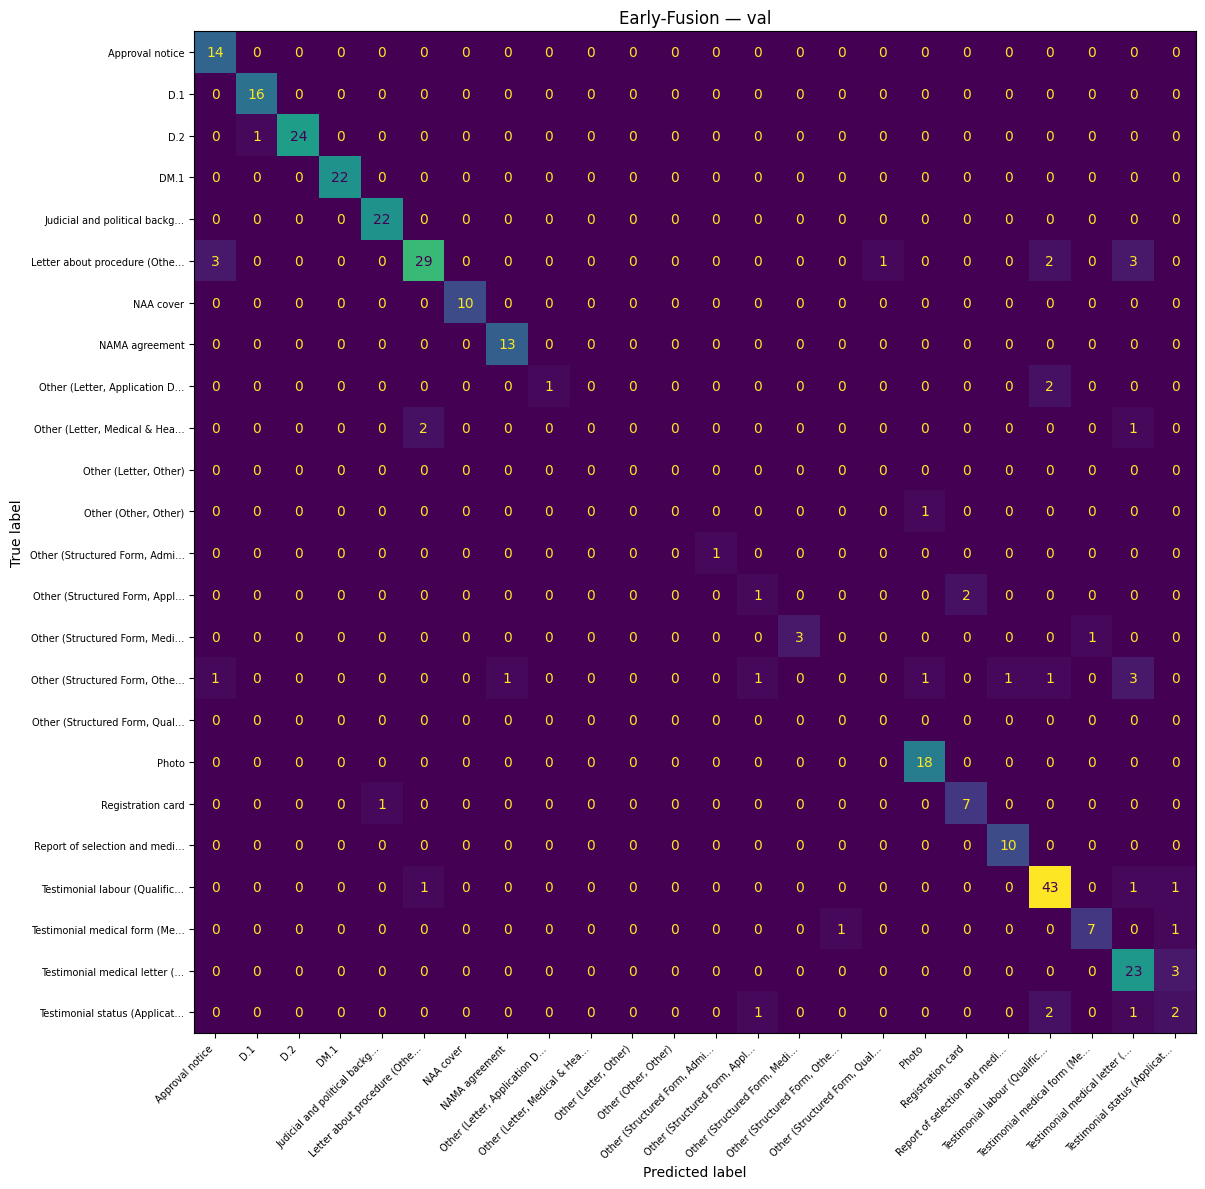


── Early-Fusion [test] ──
  Accuracy: 0.8698  |  Macro-F1: 0.6815
                               precision    recall  f1-score   support

              Approval notice       0.62      0.83      0.71         6
                          D.1       0.95      1.00      0.97        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.92      1.00      0.96        12
Letter about procedure (Othe…       0.60      0.75      0.67         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.82      1.00      0.90         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       1.00      1.00      1.00         1
Other (St

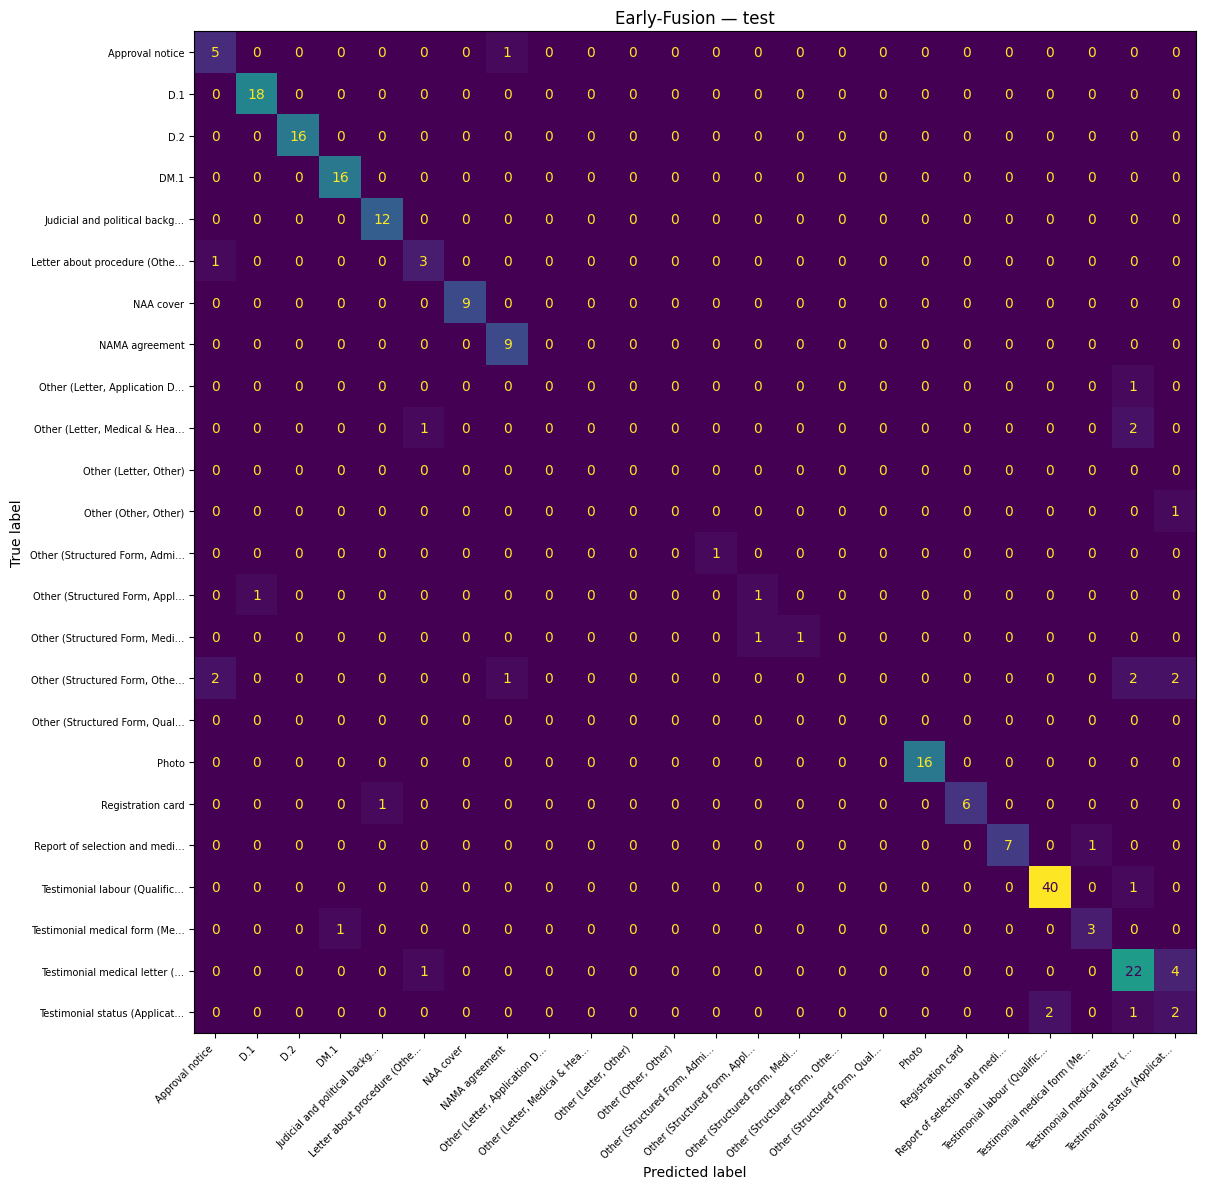

In [ ]:
class EarlyFusionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, X_eff_all: np.ndarray,
                 tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.eff_feats = X_eff_all[df.index]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.eff_feats[i], dtype=torch.float32),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class EarlyFusionModel(nn.Module):
    def __init__(self, bert_model, eff_dim=1280, bert_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.mlp  = nn.Sequential(
            nn.Linear(eff_dim + bert_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, input_ids, attention_mask, eff_feat):
        with torch.no_grad():
            cls = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.mlp(torch.cat([eff_feat, cls], dim=1))


ef_bert_base = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in ef_bert_base.parameters():
    p.requires_grad = False

ef_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
ef_tr_loader  = DataLoader(EarlyFusionDataset(df_tr, X_eff, ef_tokenizer),
                            batch_size=16, shuffle=True,  num_workers=0)
ef_va_loader  = DataLoader(EarlyFusionDataset(df_va, X_eff, ef_tokenizer),
                            batch_size=32, shuffle=False, num_workers=0)
ef_te_loader  = DataLoader(EarlyFusionDataset(df_te, X_eff, ef_tokenizer),
                            batch_size=32, shuffle=False, num_workers=0)

ef_model = EarlyFusionModel(ef_bert_base).to(DEVICE)

cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam([p for p in ef_model.parameters() if p.requires_grad],
                  lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 16):
    ef_model.train()
    for ids, mask, eff, yb in ef_tr_loader:
        ids, mask, eff, yb = ids.to(DEVICE), mask.to(DEVICE), eff.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(ids, mask, eff), yb).backward()
        nn.utils.clip_grad_norm_(ef_model.parameters(), 1.0)
        opt.step()
    sch.step()

    ef_model.eval()
    preds = []
    with torch.no_grad():
        for ids, mask, eff, _ in ef_va_loader:
            preds.extend(ef_model(ids.to(DEVICE), mask.to(DEVICE), eff.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1   = f1
        best_state = {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)

ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for ids, mask, eff, _ in ef_te_loader:
        logits = ef_model(ids.to(DEVICE), mask.to(DEVICE), eff.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())
pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)

# Evaluate on validation set
ef_model.eval()
preds_val_ef = []
with torch.no_grad():
    for ids, mask, eff, _ in ef_va_loader:
        preds_val_ef.extend(
            ef_model(ids.to(DEVICE), mask.to(DEVICE), eff.to(DEVICE)).argmax(1).cpu().tolist()
        )
evaluate('Early-Fusion', y_va, np.array(preds_val_ef), 'val')
results['Early-Fusion'] = evaluate('Early-Fusion', y_te, pred_ef_te, 'test')
results['Early-Fusion']['preds_te'] = pred_ef_te
results['Early-Fusion']['probs_te'] = probs_ef


### 9d. Late Fusion — EfficientNet-B0 FT + BERT FT (average softmax)

Averages the softmax probability vectors from the two fine-tuned single-modality models.



── Late-Fusion [test] ──
  Accuracy: 0.9256  |  Macro-F1: 0.7636
                               precision    recall  f1-score   support

              Approval notice       1.00      0.83      0.91         6
                          D.1       1.00      1.00      1.00        18
                          D.2       1.00      1.00      1.00        16
                         DM.1       0.94      1.00      0.97        16
Judicial and political backg…       0.92      1.00      0.96        12
Letter about procedure (Othe…       0.50      0.75      0.60         4
                    NAA cover       1.00      1.00      1.00         9
               NAMA agreement       0.90      1.00      0.95         9
Other (Letter, Application D…       0.00      0.00      0.00         1
Other (Letter, Medical & Hea…       0.00      0.00      0.00         3
         Other (Other, Other)       0.00      0.00      0.00         1
Other (Structured Form, Admi…       0.50      1.00      0.67         1
Other (Str

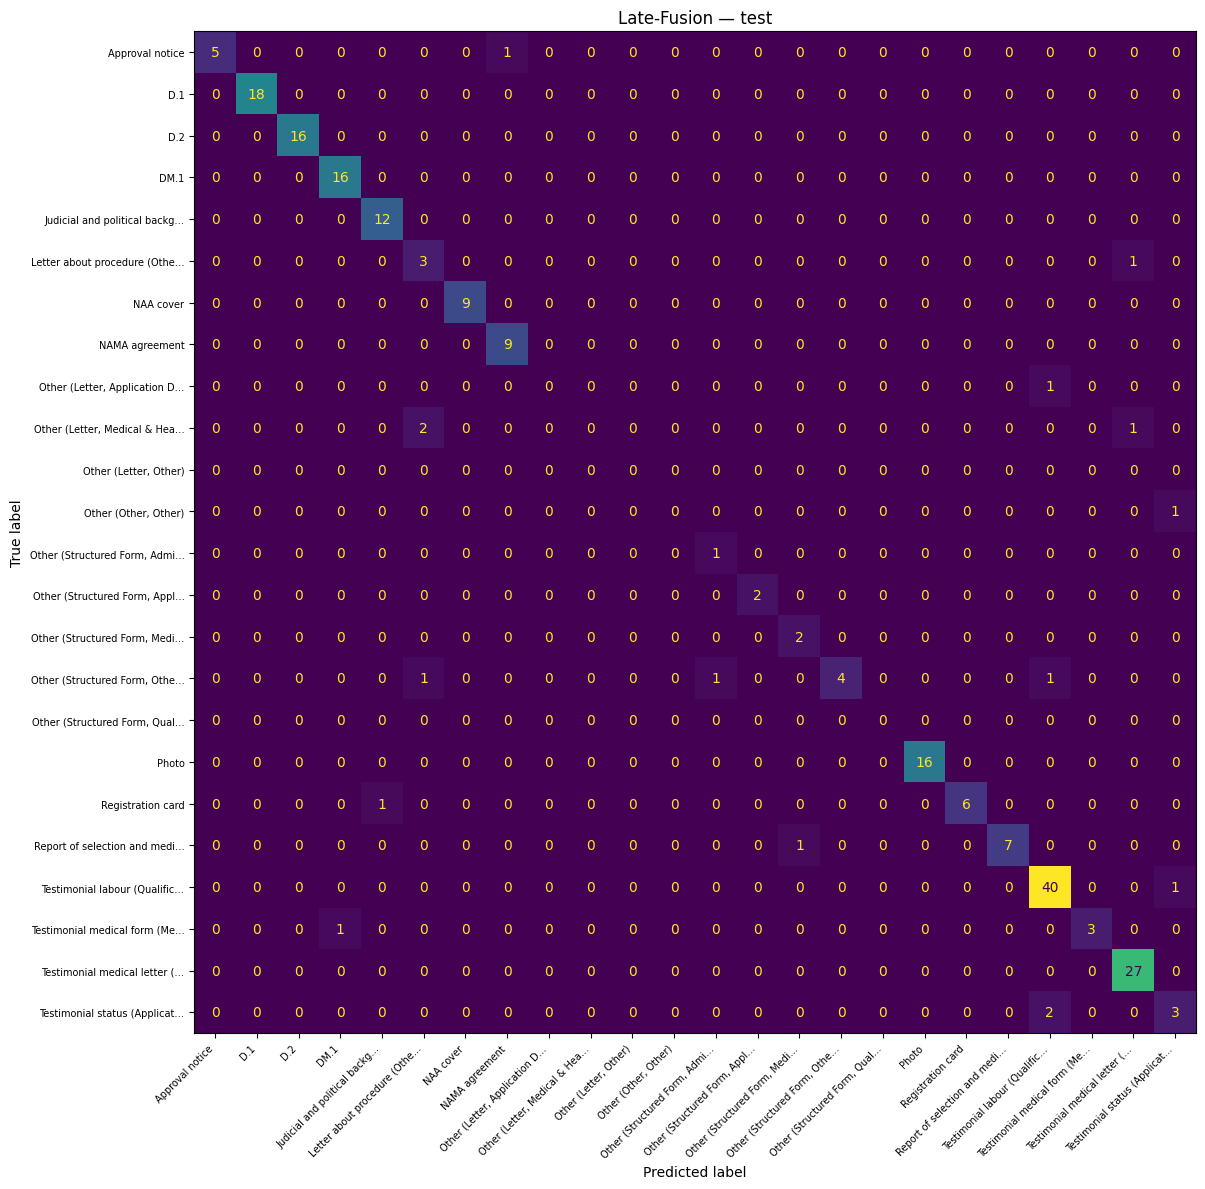

In [ ]:
probs_eff_arr  = results['EfficientNet-FT']['probs_te']   # (N_te, NUM_CLASSES)
probs_bert_arr = results['BERT-FT']['probs_te']          # (N_te, NUM_CLASSES)

probs_late = (probs_eff_arr + probs_bert_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

results['Late-Fusion'] = evaluate('Late-Fusion', y_te, pred_late, 'test')
results['Late-Fusion']['preds_te'] = pred_late
results['Late-Fusion']['probs_te'] = probs_late


## 10. Summary

In [ ]:
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model'    : name,
        'Accuracy' : round(r.get('accuracy', float('nan')), 4),
        'Macro-F1' : round(r.get('macro_f1',  float('nan')), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model').sort_values('Macro-F1', ascending=False)
print(summary_df.to_string())


                  Accuracy  Macro-F1
Model                               
BERT-FT             0.9209    0.7720
Late-Fusion         0.9256    0.7636
TEXT-CNN            0.9116    0.7566
Early-Fusion        0.8698    0.6815
XGBoost-BERT        0.8791    0.6730
EfficientNet-FT     0.7767    0.6307
XGBoost-Ensemble    0.8651    0.5795
KNN-BERT            0.7721    0.5656
LSTM-VGG16          0.7302    0.5187
XGBoost-VGG16       0.7628    0.5097
VGG16-FT            0.7116    0.5070
KNN-Ensemble        0.7535    0.5039
KNN-VGG16           0.7116    0.4753


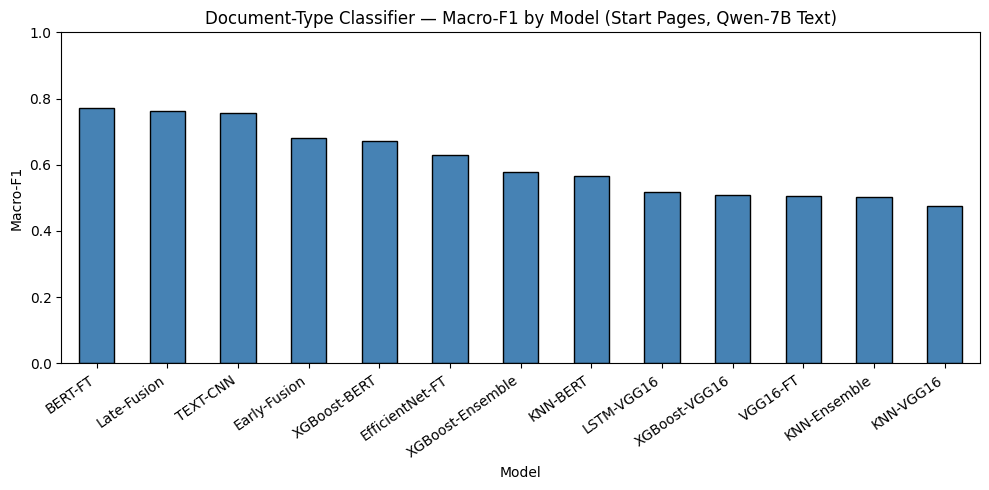

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
summary_df['Macro-F1'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Document-Type Classifier — Macro-F1 by Model (Start Pages, Qwen-7B Text)')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
